In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import spacy

from gensim.models.fasttext import load_facebook_model

## Loading the gensim model

In [2]:
ft_path = r"cc.en.300.bin"
ft_model = load_facebook_model(ft_path)
ft = ft_model.wv
embedding_dim = ft.vector_size
embedding_dim

300

## Spacy tokenizer

In [3]:
# nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# def tokenize(text):
#     doc = nlp(str(text).lower())
#     return [
#         t.lemma_
#         for t in doc
#         if not t.is_space
#         and not t.is_punct
#         and not t.is_stop
#         and len(t.text) > 1
#     ]

In [4]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def tokenize(text):
    doc = nlp(str(text).lower())
    return [t.text for t in doc if (not t.is_space) and (not t.is_punct) and (not t.is_stop) and len(t.text) > 1]

## Generating embeddings for unknown titles

In [5]:
# def title_vector(title):
#     toks = tokenize(title)
#     if len(toks) == 0:
#         return np.zeros(embedding_dim, dtype=np.float32)
#     vecs = np.stack([ft.get_vector(t) for t in toks]).astype(np.float32)
#     return vecs.mean(axis=0)

In [6]:
def title_vector(title):
    toks = tokenize(title)
    bigrams = [toks[i] + "_" + toks[i+1] for i in range(len(toks)-1)]
    toks = toks + bigrams
    if len(toks) == 0:
        return np.zeros(embedding_dim, dtype=np.float32)
    vecs = np.stack([ft.get_vector(t) for t in toks]).astype(np.float32)
    return vecs.mean(axis=0)

## Labels in data and train test split

In [7]:
data = pd.read_csv("final_recipes_dataset.csv")
data = data.drop(columns=["Photo"])

In [8]:
data = data.copy()
data["NormTitle"] = data["NormTitle"].fillna("")

candidate_cols = [c for c in data.columns if c != "NormTitle"]

label_cols = []
for c in candidate_cols:
    s = pd.to_numeric(data[c], errors="coerce")
    if s.isna().mean() > 0.01:
        continue
    vals = set(s.dropna().unique().tolist())
    if vals.issubset({0, 1}):
        label_cols.append(c)

data[label_cols] = data[label_cols].astype(np.float32)

print("n_labels:", len(label_cols))

n_labels: 1138


In [9]:
train_df, temp_df = train_test_split(data, test_size=0.2, random_state=123, shuffle=True)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=123, shuffle=True)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

## Data loaders

In [10]:
class FastTextDataset(Dataset):
    def __init__(self, df, label_cols):
        self.texts = df["NormTitle"].tolist()
        self.Y = df[label_cols].values.astype(np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        x = title_vector(self.texts[i])
        y = self.Y[i]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_ds = FastTextDataset(train_df, label_cols)
val_ds   = FastTextDataset(val_df, label_cols)
test_ds  = FastTextDataset(test_df, label_cols)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

## Neural network

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

class FoodClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

model = FoodClassifier(embedding_dim, 256, len(label_cols)).to(device)

## Loss function and Adam optimizer

In [12]:
train_Y = train_df[label_cols].values.astype(np.float32)

pos = train_Y.sum(axis=0)
neg = train_Y.shape[0] - pos

pos_weight = torch.tensor(
    np.sqrt((neg + 1e-6) / (pos + 1e-6)),
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

## Jaccard and other metrics

In [13]:
@torch.no_grad()
def jaccard_from_logits(logits, y_true, threshold):
    probs = torch.sigmoid(logits)
    y_pred = (probs >= threshold).float()
    inter = (y_pred * y_true).sum(dim=1)
    union = ((y_pred + y_true) > 0).float().sum(dim=1)
    return (inter / (union + 1e-9)).mean().item()

@torch.no_grad()
def micro_f1_from_logits(logits, y_true, threshold):
    probs = torch.sigmoid(logits)
    y_pred = (probs >= threshold).float()

    tp = (y_pred * y_true).sum().item()
    fp = (y_pred * (1 - y_true)).sum().item()
    fn = ((1 - y_pred) * y_true).sum().item()

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    return f1, precision, recall

@torch.no_grad()
def precision_recall_at_k(logits, y_true, k):
    topk = torch.topk(logits, k=k, dim=1).indices
    y_true_bool = y_true.bool()

    p_list, r_list = [], []
    for i in range(logits.size(0)):
        pred_idx = topk[i]
        hit = y_true_bool[i, pred_idx].sum().item()
        true_cnt = y_true_bool[i].sum().item()
        p_list.append(hit / k)
        r_list.append(hit / (true_cnt + 1e-9))

    return float(np.mean(p_list)), float(np.mean(r_list))

## Training

In [65]:
import torch
from tqdm import tqdm

def run_epoch(loader, train, model, criterion, optimizer, device):
    model.train() if train else model.eval()

    total_loss = 0.0
    all_logits, all_y = [], []

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for xb, yb in tqdm(loader, disable=not train):
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * yb.size(0)
            all_logits.append(logits.detach().cpu())
            all_y.append(yb.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, torch.cat(all_logits, dim=0), torch.cat(all_y, dim=0)

train_loss_hist = []
val_loss_hist   = []
val_f1_hist     = []
val_j_hist      = []
val_p10_hist    = []
val_r10_hist    = []

best_val_j = -1
best_state = None
num_epochs = 20

for epoch in range(num_epochs):
    tr_loss, _, _ = run_epoch(train_loader, True, model, criterion, optimizer, device)
    va_loss, va_logits, va_y = run_epoch(val_loader, False, model, criterion, optimizer, device)

    va_f1, va_p, va_r = micro_f1_from_logits(va_logits, va_y, threshold=0.2)
    va_j = jaccard_from_logits(va_logits, va_y, threshold=0.2)
    p10, r10 = precision_recall_at_k(va_logits, va_y, k=10)

    train_loss_hist.append(tr_loss)
    val_loss_hist.append(va_loss)
    val_f1_hist.append(va_f1)
    val_j_hist.append(va_j)
    val_p10_hist.append(p10)
    val_r10_hist.append(r10)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | train loss {tr_loss:.4f} | val loss {va_loss:.4f} | micro-F1 {va_f1:.4f} | Jacc {va_j:.4f} | P@10 {p10:.4f} | R@10 {r10:.4f}")

    if va_j > best_val_j:
        best_val_j = va_j
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

100%|██████████| 10/10 [00:01<00:00,  7.17it/s]


Epoch 01/20 | train loss 0.1141 | val loss 71.5530 | micro-F1 0.1309 | Jacc 0.0803 | P@10 0.0800 | R@10 0.2571


100%|██████████| 10/10 [00:01<00:00,  7.18it/s]


Epoch 02/20 | train loss 0.1055 | val loss 74.2929 | micro-F1 0.1243 | Jacc 0.0760 | P@10 0.0888 | R@10 0.2735


100%|██████████| 10/10 [00:01<00:00,  7.36it/s]


...

Epoch 18/20 | train loss 0.0460 | val loss 113.1415 | micro-F1 0.1099 | Jacc 0.0632 | P@10 0.0762 | R@10 0.2190


100%|██████████| 10/10 [00:01<00:00,  6.37it/s]


Epoch 19/20 | train loss 0.0448 | val loss 108.9310 | micro-F1 0.1036 | Jacc 0.0614 | P@10 0.0762 | R@10 0.2232


100%|██████████| 10/10 [00:01<00:00,  6.61it/s]


Epoch 20/20 | train loss 0.0433 | val loss 113.8765 | micro-F1 0.1125 | Jacc 0.0653 | P@10 0.0788 | R@10 0.2235


## Evaluation

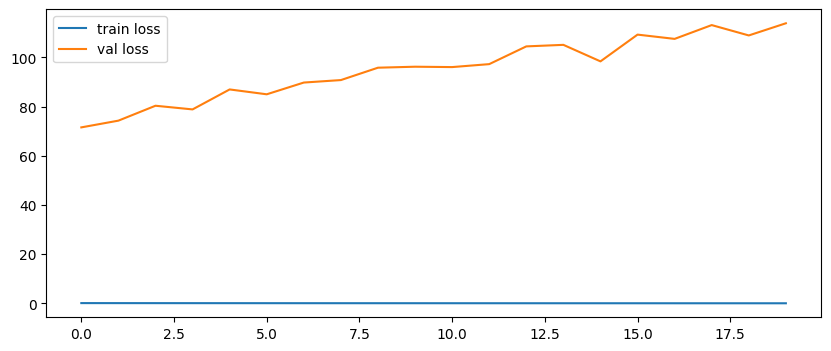

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(train_loss_hist, label="train loss")
plt.plot(val_loss_hist, label="val loss")
plt.legend()
plt.show()

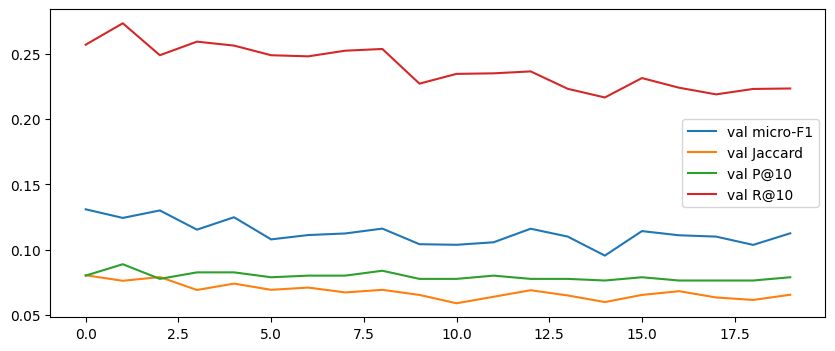

In [67]:
plt.figure(figsize=(10,4))
plt.plot(val_f1_hist, label="val micro-F1")
plt.plot(val_j_hist, label="val Jaccard")
plt.plot(val_p10_hist, label="val P@10")
plt.plot(val_r10_hist, label="val R@10")
plt.legend()
plt.show()

In [68]:
model.load_state_dict(best_state)

te_loss, te_logits, te_y = run_epoch(test_loader, False, model, criterion, optimizer, device)

te_f1, te_p, te_r = micro_f1_from_logits(te_logits, te_y, threshold=0.2)
te_j = jaccard_from_logits(te_logits, te_y, threshold=0.2)
p10, r10 = precision_recall_at_k(te_logits, te_y, k=10)

print(f"loss {te_loss:.4f} | micro-F1 {te_f1:.4f} (P {te_p:.4f} R {te_r:.4f}) | Jacc {te_j:.4f} | P@10 {p10:.4f} | R@10 {r10:.4f}")

loss 85.5001 | micro-F1 0.0948 (P 0.0642 R 0.1813) | Jacc 0.0446 | P@10 0.0688 | R@10 0.1670


In [69]:
model.load_state_dict(best_state)

@torch.no_grad()
def predict_title(title, topk=10):
    model.eval()
    x = torch.tensor(title_vector(title), dtype=torch.float32).unsqueeze(0).to(device)
    logits = model(x).cpu().squeeze(0)
    idx = torch.topk(logits, k=topk).indices.numpy().tolist()
    labels = [label_cols[i] for i in idx]
    scores = torch.sigmoid(logits[idx]).numpy().tolist()
    return list(zip(labels, scores))

In [70]:
predict_title("pizza")

[('mozzarella', 0.9122588634490967),
 ('yeast', 0.9059227108955383),
 ('pizzasauce', 0.8422877192497253),
 ('oregano', 0.8213021755218506),
 ('mushroom', 0.757377028465271),
 ('pepperoni', 0.7336632013320923),
 ('red pepper', 0.49379149079322815),
 ('tomato sauce', 0.48704567551612854),
 ('cheese', 0.4595963656902313),
 ('parmesan cheese', 0.3869015872478485)]

In [71]:
predict_title("sushi")

[('nori', 0.7077857851982117),
 ('wasabi', 0.6447047591209412),
 ('rice', 0.6042383313179016),
 ('mushroom', 0.477267861366272),
 ('top', 0.37739306688308716),
 ('negitoro', 0.3181743323802948),
 ('sea urchin', 0.3144054710865021),
 ('mirin', 0.28440526127815247),
 ('seafood', 0.2832891047000885),
 ('tofu', 0.26315101981163025)]

In [72]:
predict_title("chicken curry")

[('chicken', 0.8733282685279846),
 ('garam masala', 0.8698315620422363),
 ('turmeric', 0.8040667176246643),
 ('coconut milk', 0.6522209048271179),
 ('red chile powder', 0.6372106671333313),
 ('kimiri', 0.5826801061630249),
 ('lemongrass', 0.5819315314292908),
 ('turmeric root', 0.5799760222434998),
 ('gula jawa', 0.5492083430290222),
 ('kaffir lime leave', 0.5392758250236511)]

In [73]:
predict_title("spaghetti")

[('spaghetti', 0.6877147555351257),
 ('pasta sauce', 0.40130341053009033),
 ('mozzarella', 0.3107447028160095),
 ('tomato paste', 0.2680129110813141),
 ('wheat flour', 0.2532065510749817),
 ('potato', 0.2461031824350357),
 ('potash', 0.2320881187915802),
 ('pork mince', 0.2102334201335907),
 ('rice', 0.20996765792369843),
 ('fennel', 0.20050953328609467)]

In [74]:
predict_title("cake")

[('egg white', 0.7526744604110718),
 ('almond flavor', 0.5749373435974121),
 ('vanilla essence', 0.5729908347129822),
 ('cream', 0.5541658401489258),
 ('cream cheese', 0.537621021270752),
 ('egg yolk', 0.5299243927001953),
 ('cake', 0.4851281940937042),
 ('vanilla powder', 0.48404374718666077),
 ('pectin', 0.4820410907268524),
 ('creamer', 0.47895142436027527)]

In [75]:
predict_title("cucumber soup")

[('palm oil', 0.41563400626182556),
 ('potato', 0.28778186440467834),
 ('beef', 0.2661246657371521),
 ('dry fish', 0.2608940303325653),
 ('crayfish', 0.25774165987968445),
 ('celery root', 0.24898892641067505),
 ('portobello mushroom', 0.2484208643436432),
 ('stock cube', 0.23662419617176056),
 ('miso', 0.2329982966184616),
 ('chicken wing', 0.22731062769889832)]

In [76]:
predict_title("apple pie")

[('pie crust', 0.5208171010017395),
 ('nutmeg', 0.31747952103614807),
 ('egg yolk', 0.3145407438278198),
 ('apple', 0.30680790543556213),
 ('crisco', 0.2917546331882477),
 ('cheese', 0.2804582417011261),
 ('cream', 0.27729707956314087),
 ('breadcrumb', 0.25955259799957275),
 ('italian seasoning', 0.25162187218666077),
 ('potato', 0.24710863828659058)]

## Saving the model as a file

In [77]:
import json
import torch

artifact = {
    "state_dict": model.state_dict(),
    "embedding_dim": int(embedding_dim),
    "hidden_dim": 256,
    "label_cols": label_cols,
    "threshold": 0.2
}

torch.save(artifact, "recipe_fasttext_mlp.pt")

with open("recipe_fasttext_mlp_labels.json", "w", encoding="utf-8") as f:
    json.dump(label_cols, f, ensure_ascii=False, indent=2)

# Hyperparameters testing

### Test function

In [78]:
def test_hiperparameters(
    hidden_dim=256,
    dropout=0.4,
    lr=3e-3,
    weight_dec=1e-2,
    n_epochs=20,
    threshold=0.2,
    k_at=10,
    model_prefix="model",
):
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import matplotlib.pyplot as plt

    device = "cuda" if torch.cuda.is_available() else "cpu"

    class FoodClassifierHP(nn.Module):
        def __init__(self, in_dim, hidden_dim, out_dim, dropout):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, out_dim),
            )

        def forward(self, x):
            return self.net(x)

    do_tag = f"{int(dropout*10):02d}"
    model_name = f"{model_prefix}_hd{hidden_dim}_do{do_tag}"

    model = FoodClassifierHP(embedding_dim, hidden_dim, len(label_cols), dropout).to(device)
    globals()[model_name] = model

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_dec)

    train_loss_hist = []
    val_loss_hist   = []
    val_f1_hist     = []
    val_p10_hist    = []
    val_r10_hist    = []
    val_jacc_hist   = []

    best_val_f1 = -1
    best_state = None

    print(f"\n===== TRAINING {model_name} (hd={hidden_dim}, do={dropout}) =====")
    for epoch in range(n_epochs):
        tr_loss, _, _ = run_epoch(train_loader, True, model, criterion, optimizer, device)
        va_loss, va_logits, va_y = run_epoch(val_loader, False, model, criterion, optimizer, device)

        va_f1, va_p, va_r = micro_f1_from_logits(va_logits, va_y, threshold=threshold)
        va_j = jaccard_from_logits(va_logits, va_y, threshold=threshold)
        p10, r10 = precision_recall_at_k(va_logits, va_y, k=k_at)

        train_loss_hist.append(tr_loss)
        val_loss_hist.append(va_loss)
        val_f1_hist.append(va_f1)
        val_p10_hist.append(p10)
        val_r10_hist.append(r10)
        val_jacc_hist.append(va_j)

        print(
            f"Epoch {epoch+1:02d}/{n_epochs} | "
            f"train loss {tr_loss:.4f} | val loss {va_loss:.4f} | "
            f"val micro-F1 {va_f1:.4f} (P {va_p:.4f} R {va_r:.4f}) | "
            f"Jacc {va_j:.4f} | P@{k_at} {p10:.4f} | R@{k_at} {r10:.4f}"
        )

        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    plt.figure(figsize=(10,4))
    plt.plot(train_loss_hist, label="train loss")
    plt.plot(val_loss_hist, label="val loss")
    plt.title(model_name)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(val_f1_hist, label="val micro-F1")
    plt.plot(val_p10_hist, label=f"val P@{k_at}")
    plt.plot(val_r10_hist, label=f"val R@{k_at}")
    plt.title(model_name)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(val_jacc_hist, label="val Jaccard")
    plt.title(model_name)
    plt.legend()
    plt.show()

    model.load_state_dict(best_state)

    te_loss, te_logits, te_y = run_epoch(test_loader, False, model, criterion, optimizer, device)
    te_f1, te_p, te_r = micro_f1_from_logits(te_logits, te_y, threshold=threshold)
    te_j = jaccard_from_logits(te_logits, te_y, threshold=threshold)
    p10, r10 = precision_recall_at_k(te_logits, te_y, k=k_at)

    print("\n=== TEST ===")
    print(
        f"loss {te_loss:.4f} | micro-F1 {te_f1:.4f} (P {te_p:.4f} R {te_r:.4f}) | "
        f"Jacc {te_j:.4f} | P@{k_at} {p10:.4f} | R@{k_at} {r10:.4f}"
    )
    

Testing hidden layer


===== TRAINING model_hd64_do03 (hd=64, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  6.15it/s]


Epoch 01/20 | train loss 0.7614 | val loss 15.1250 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0013 | R@10 0.0014


100%|██████████| 10/10 [00:01<00:00,  6.70it/s]


Epoch 02/20 | train loss 0.7419 | val loss 15.2577 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0025 | R@10 0.0035


...

Epoch 18/20 | train loss 0.2254 | val loss 47.6963 | val micro-F1 0.0403 (P 0.0220 R 0.2453) | Jacc 0.0342 | P@10 0.0638 | R@10 0.2143


100%|██████████| 10/10 [00:01<00:00,  6.55it/s]


Epoch 19/20 | train loss 0.2081 | val loss 49.2113 | val micro-F1 0.0464 (P 0.0259 R 0.2205) | Jacc 0.0440 | P@10 0.0638 | R@10 0.2131


100%|██████████| 10/10 [00:01<00:00,  6.42it/s]


Epoch 20/20 | train loss 0.1957 | val loss 54.7390 | val micro-F1 0.0800 (P 0.0509 R 0.1863) | Jacc 0.0655 | P@10 0.0675 | R@10 0.2203


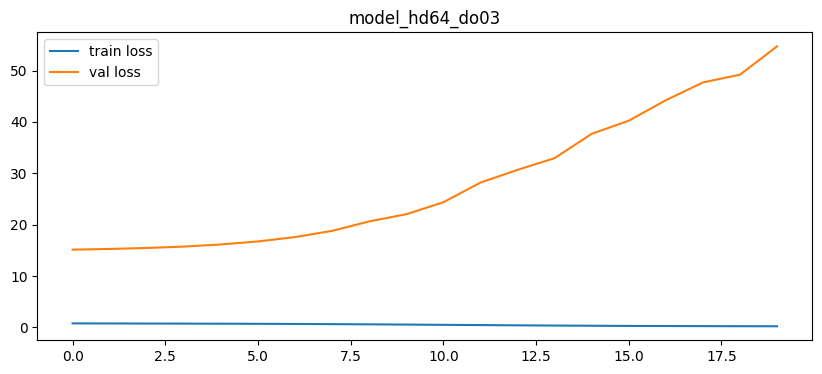

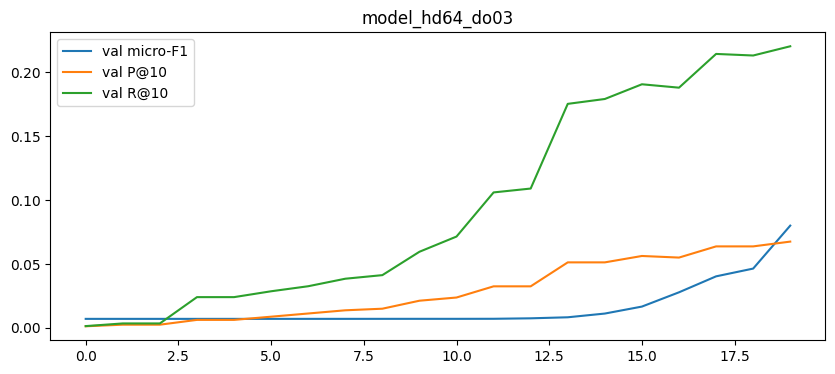

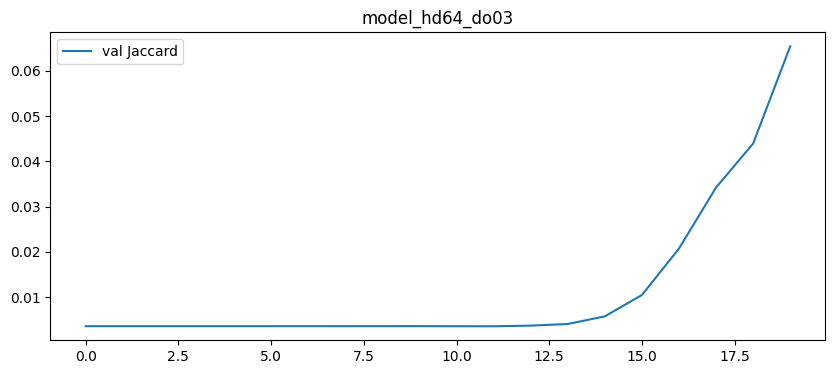


=== TEST ===
loss 62.6035 | micro-F1 0.0623 (P 0.0386 R 0.1608) | Jacc 0.0339 | P@10 0.0525 | R@10 0.1364


In [79]:
test_hiperparameters(hidden_dim=64, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd128_do03 (hd=128, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  6.07it/s]


Epoch 01/20 | train loss 0.7646 | val loss 15.0927 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0100 | R@10 0.0323


100%|██████████| 10/10 [00:01<00:00,  6.50it/s]


Epoch 02/20 | train loss 0.7419 | val loss 15.2547 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0075 | R@10 0.0200


...

Epoch 18/20 | train loss 0.1586 | val loss 61.9212 | val micro-F1 0.0958 (P 0.0589 R 0.2578) | Jacc 0.0686 | P@10 0.0813 | R@10 0.2688


100%|██████████| 10/10 [00:01<00:00,  5.98it/s]


Epoch 19/20 | train loss 0.1470 | val loss 63.8266 | val micro-F1 0.0992 (P 0.0614 R 0.2578) | Jacc 0.0634 | P@10 0.0813 | R@10 0.2692


100%|██████████| 10/10 [00:01<00:00,  6.06it/s]


Epoch 20/20 | train loss 0.1378 | val loss 68.5144 | val micro-F1 0.1142 (P 0.0744 R 0.2453) | Jacc 0.0680 | P@10 0.0813 | R@10 0.2762


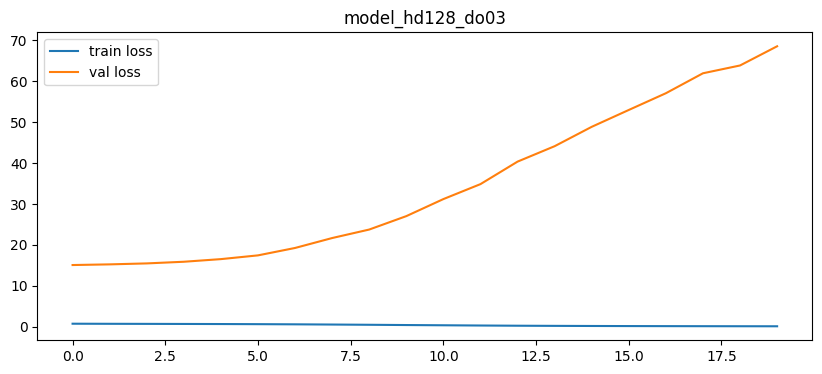

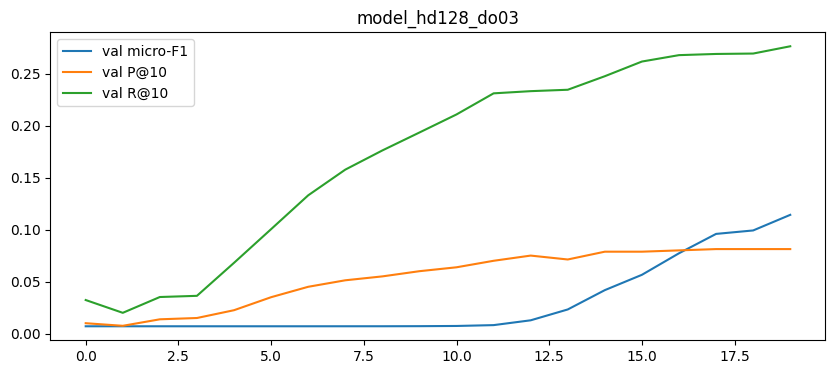

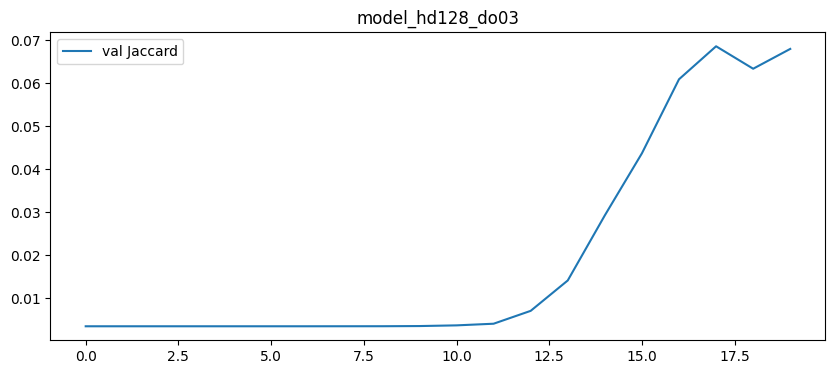


=== TEST ===
loss 77.0837 | micro-F1 0.0875 (P 0.0555 R 0.2076) | Jacc 0.0445 | P@10 0.0725 | R@10 0.1797


In [80]:
test_hiperparameters(hidden_dim=128, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd256_do03 (hd=256, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  6.54it/s]


Epoch 01/20 | train loss 0.7561 | val loss 15.0408 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0075 | R@10 0.0143


100%|██████████| 10/10 [00:01<00:00,  6.56it/s]


Epoch 02/20 | train loss 0.7306 | val loss 15.3005 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0112 | R@10 0.0264


...

Epoch 18/20 | train loss 0.0924 | val loss 84.1335 | val micro-F1 0.1378 (P 0.0945 R 0.2547) | Jacc 0.1019 | P@10 0.0875 | R@10 0.2716


100%|██████████| 10/10 [00:01<00:00,  6.21it/s]


Epoch 19/20 | train loss 0.0863 | val loss 77.2172 | val micro-F1 0.1058 (P 0.0651 R 0.2826) | Jacc 0.0712 | P@10 0.0863 | R@10 0.2824


100%|██████████| 10/10 [00:01<00:00,  6.01it/s]


Epoch 20/20 | train loss 0.0796 | val loss 87.7783 | val micro-F1 0.1272 (P 0.0848 R 0.2547) | Jacc 0.0822 | P@10 0.0875 | R@10 0.2896


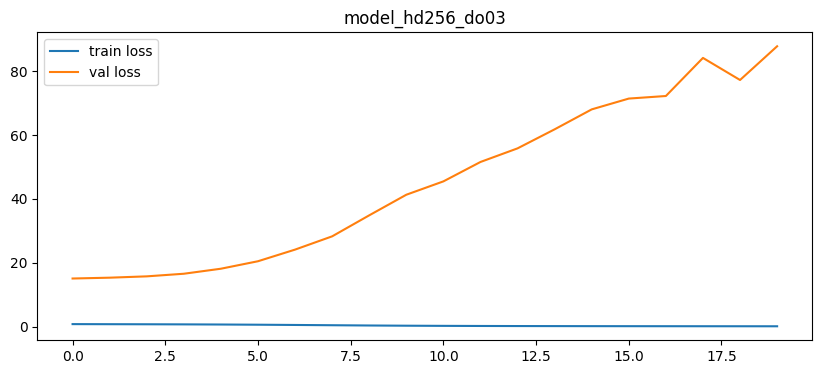

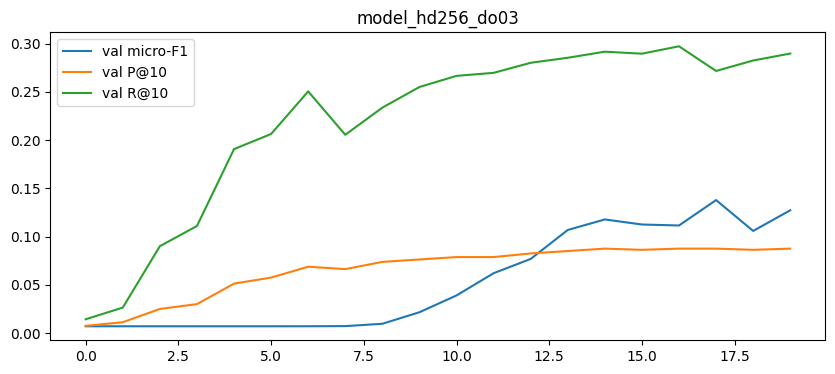

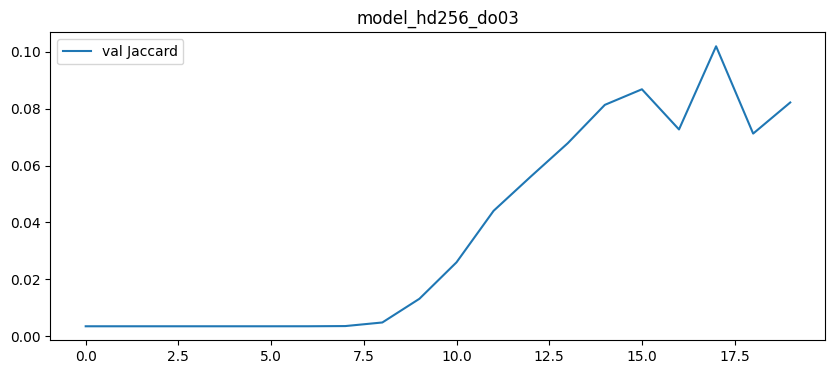


=== TEST ===
loss 94.7181 | micro-F1 0.0939 (P 0.0634 R 0.1813) | Jacc 0.0437 | P@10 0.0650 | R@10 0.1382


In [81]:
test_hiperparameters(hidden_dim=256, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd512_do03 (hd=512, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.95it/s]


Epoch 01/20 | train loss 0.7567 | val loss 15.0835 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0063 | R@10 0.0126


100%|██████████| 10/10 [00:01<00:00,  6.05it/s]


Epoch 02/20 | train loss 0.7229 | val loss 15.5048 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0288 | R@10 0.0984


...

Epoch 18/20 | train loss 0.0505 | val loss 95.5989 | val micro-F1 0.1294 (P 0.0848 R 0.2733) | Jacc 0.0783 | P@10 0.0900 | R@10 0.2837


100%|██████████| 10/10 [00:01<00:00,  6.05it/s]


Epoch 19/20 | train loss 0.0467 | val loss 96.0667 | val micro-F1 0.1221 (P 0.0783 R 0.2764) | Jacc 0.0683 | P@10 0.0862 | R@10 0.2746


100%|██████████| 10/10 [00:01<00:00,  5.76it/s]


Epoch 20/20 | train loss 0.0431 | val loss 102.2950 | val micro-F1 0.1321 (P 0.0881 R 0.2640) | Jacc 0.0746 | P@10 0.0912 | R@10 0.2872


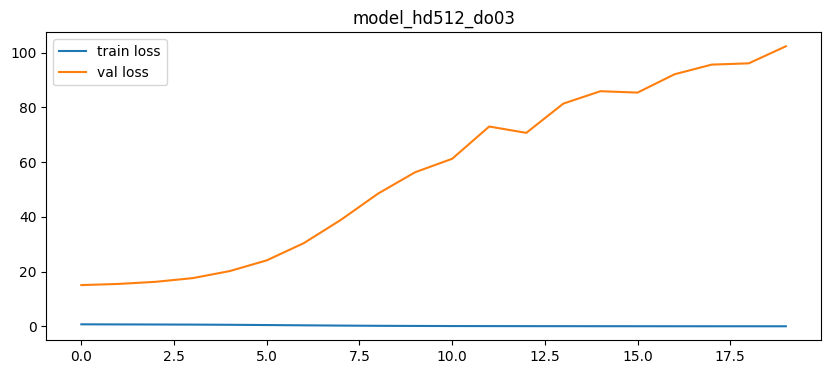

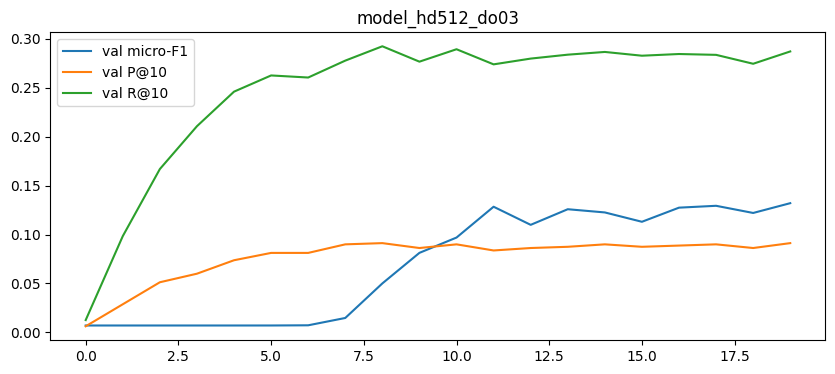

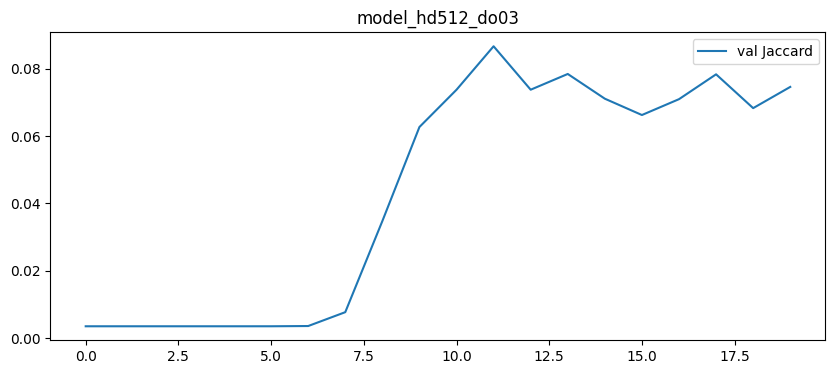


=== TEST ===
loss 114.4315 | micro-F1 0.0979 (P 0.0652 R 0.1959) | Jacc 0.0422 | P@10 0.0663 | R@10 0.1616


In [82]:
test_hiperparameters(hidden_dim=512, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)

Since micro-F1 increases with hidden_dim I decided to make some more tests


===== TRAINING model_hd1024_do03 (hd=1024, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  6.10it/s]


Epoch 01/20 | train loss 0.7541 | val loss 15.3104 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0263 | R@10 0.0961


100%|██████████| 10/10 [00:01<00:00,  6.13it/s]


Epoch 02/20 | train loss 0.7084 | val loss 15.9785 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0537 | R@10 0.1856


...

Epoch 18/20 | train loss 0.0265 | val loss 106.8514 | val micro-F1 0.1201 (P 0.0821 R 0.2236) | Jacc 0.0712 | P@10 0.0850 | R@10 0.2612


100%|██████████| 10/10 [00:01<00:00,  6.11it/s]


Epoch 19/20 | train loss 0.0248 | val loss 106.5644 | val micro-F1 0.1243 (P 0.0840 R 0.2391) | Jacc 0.0726 | P@10 0.0850 | R@10 0.2656


100%|██████████| 10/10 [00:01<00:00,  6.10it/s]


Epoch 20/20 | train loss 0.0223 | val loss 108.6551 | val micro-F1 0.1226 (P 0.0836 R 0.2298) | Jacc 0.0711 | P@10 0.0875 | R@10 0.2647


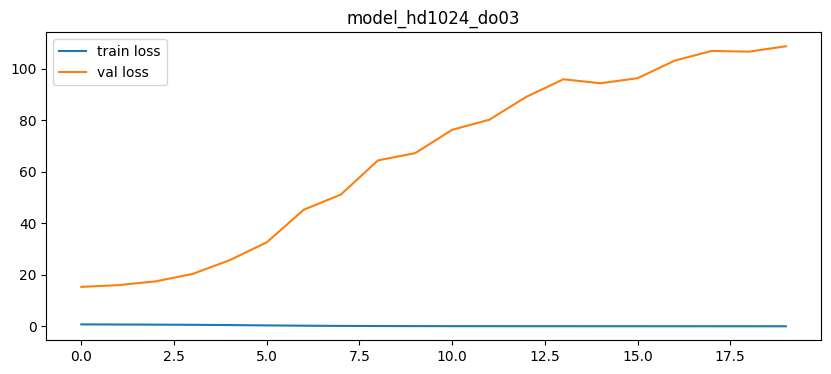

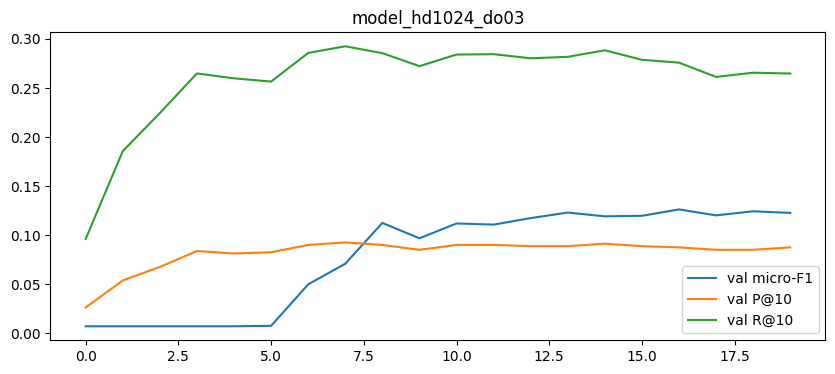

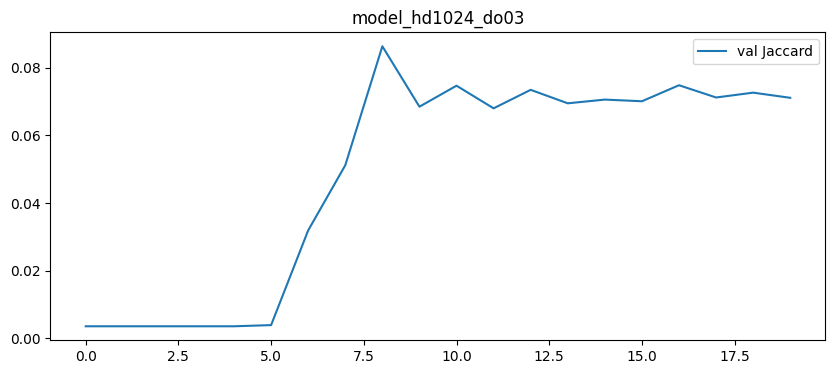


=== TEST ===
loss 115.3200 | micro-F1 0.1125 (P 0.0761 R 0.2164) | Jacc 0.0546 | P@10 0.0700 | R@10 0.1780


In [83]:
test_hiperparameters(hidden_dim=1024, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd2048_do03 (hd=2048, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.35it/s]


Epoch 01/20 | train loss 0.7532 | val loss 15.4383 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0400 | R@10 0.1361


100%|██████████| 10/10 [00:01<00:00,  5.70it/s]


Epoch 02/20 | train loss 0.6904 | val loss 16.7021 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0713 | R@10 0.2092


...

Epoch 18/20 | train loss 0.0154 | val loss 121.0346 | val micro-F1 0.1448 (P 0.1064 R 0.2267) | Jacc 0.0771 | P@10 0.0938 | R@10 0.2719


100%|██████████| 10/10 [00:02<00:00,  4.67it/s]


Epoch 19/20 | train loss 0.0139 | val loss 126.1219 | val micro-F1 0.1501 (P 0.1164 R 0.2112) | Jacc 0.0800 | P@10 0.0925 | R@10 0.2670


100%|██████████| 10/10 [00:02<00:00,  4.81it/s]


Epoch 20/20 | train loss 0.0131 | val loss 128.1795 | val micro-F1 0.1467 (P 0.1152 R 0.2019) | Jacc 0.0763 | P@10 0.0900 | R@10 0.2732


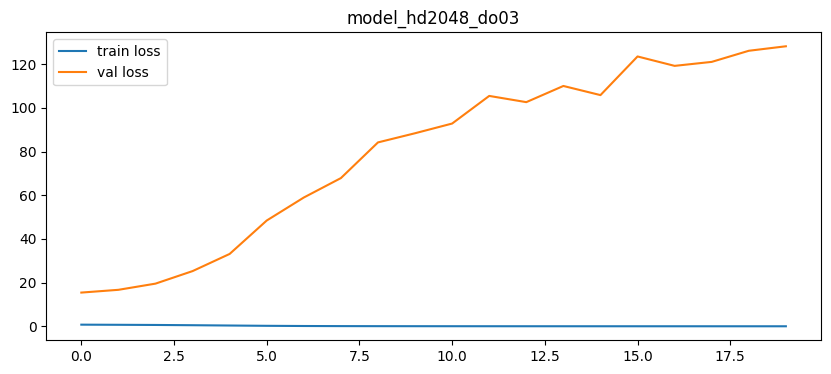

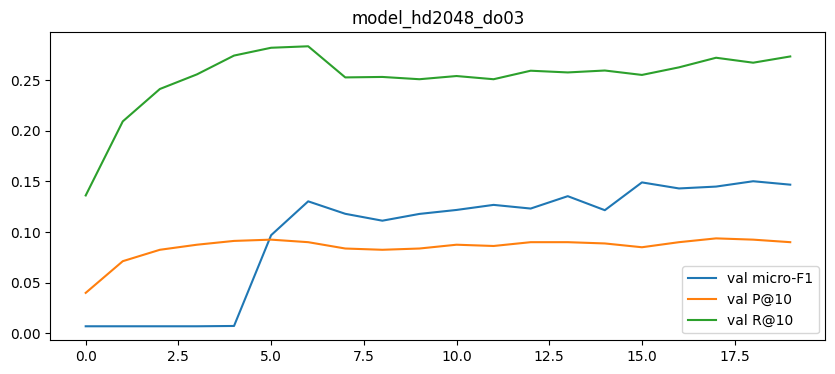

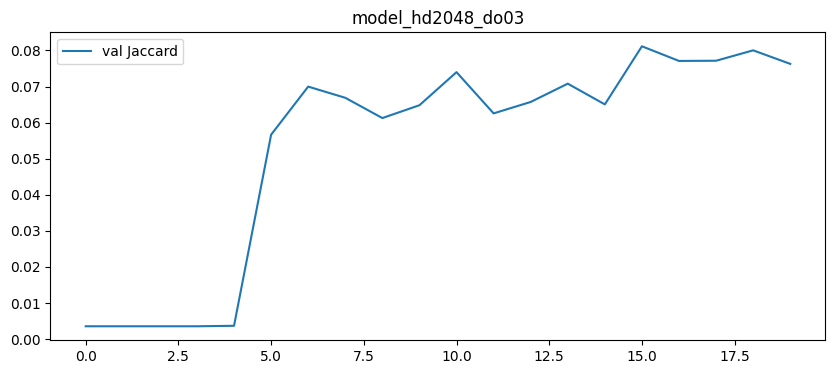


=== TEST ===
loss 143.2781 | micro-F1 0.1289 (P 0.1019 R 0.1754) | Jacc 0.0545 | P@10 0.0737 | R@10 0.1785


In [84]:
test_hiperparameters(hidden_dim=2048, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd4096_do03 (hd=4096, do=0.3) =====


100%|██████████| 10/10 [00:02<00:00,  3.79it/s]


Epoch 01/20 | train loss 0.7524 | val loss 15.8742 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0625 | R@10 0.1979


100%|██████████| 10/10 [00:02<00:00,  3.77it/s]


Epoch 02/20 | train loss 0.6540 | val loss 18.6015 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0588 | R@10 0.1630


...

Epoch 18/20 | train loss 0.0097 | val loss 130.2732 | val micro-F1 0.1502 (P 0.1219 R 0.1957) | Jacc 0.0857 | P@10 0.0887 | R@10 0.2673


100%|██████████| 10/10 [00:01<00:00,  8.20it/s]


Epoch 19/20 | train loss 0.0085 | val loss 134.2439 | val micro-F1 0.1535 (P 0.1290 R 0.1894) | Jacc 0.0877 | P@10 0.0863 | R@10 0.2589


100%|██████████| 10/10 [00:01<00:00,  5.70it/s]


Epoch 20/20 | train loss 0.0080 | val loss 133.8748 | val micro-F1 0.1535 (P 0.1276 R 0.1925) | Jacc 0.0890 | P@10 0.0887 | R@10 0.2694


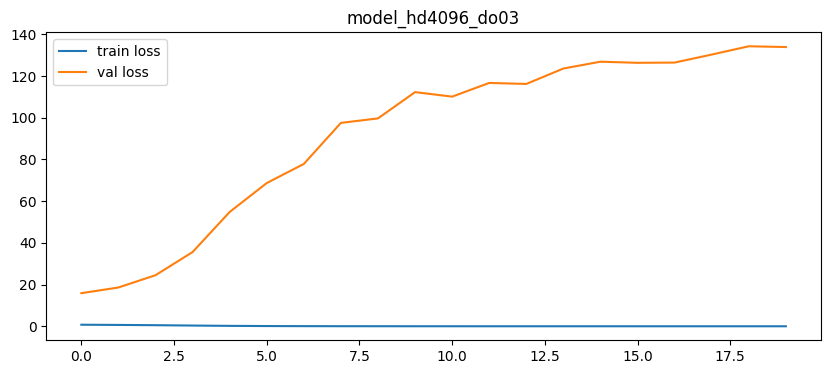

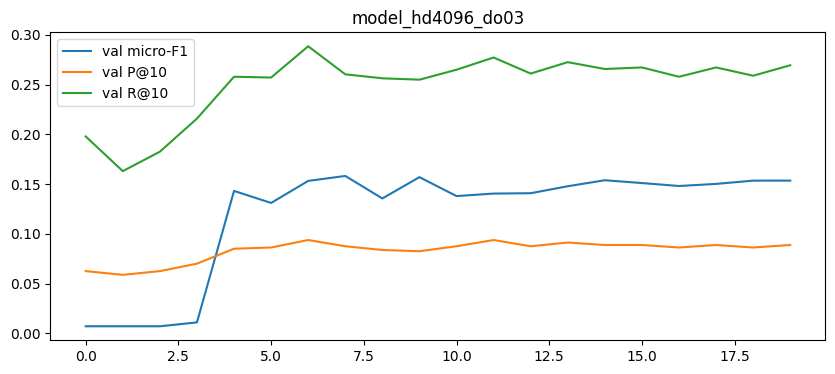

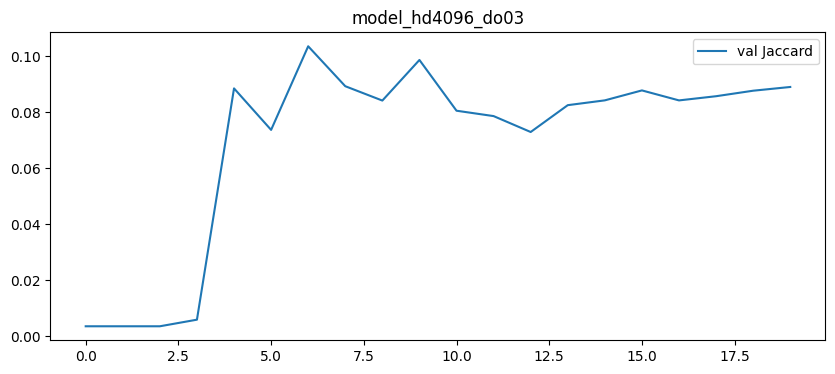


=== TEST ===
loss 112.5504 | micro-F1 0.1032 (P 0.0861 R 0.1287) | Jacc 0.0493 | P@10 0.0675 | R@10 0.1695


In [85]:
test_hiperparameters(hidden_dim=4096, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:02<00:00,  4.76it/s]


Epoch 01/20 | train loss 0.7563 | val loss 16.6554 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0512 | R@10 0.1414


100%|██████████| 10/10 [00:01<00:00,  5.84it/s]


Epoch 02/20 | train loss 0.6232 | val loss 21.9551 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0575 | R@10 0.1728


...

Epoch 18/20 | train loss 0.0067 | val loss 146.3864 | val micro-F1 0.1511 (P 0.1285 R 0.1832) | Jacc 0.0857 | P@10 0.0838 | R@10 0.2543


100%|██████████| 10/10 [00:01<00:00,  5.93it/s]


Epoch 19/20 | train loss 0.0065 | val loss 143.8638 | val micro-F1 0.1554 (P 0.1303 R 0.1925) | Jacc 0.0862 | P@10 0.0838 | R@10 0.2588


100%|██████████| 10/10 [00:02<00:00,  4.33it/s]


Epoch 20/20 | train loss 0.0062 | val loss 148.4061 | val micro-F1 0.1478 (P 0.1284 R 0.1739) | Jacc 0.0838 | P@10 0.0813 | R@10 0.2573


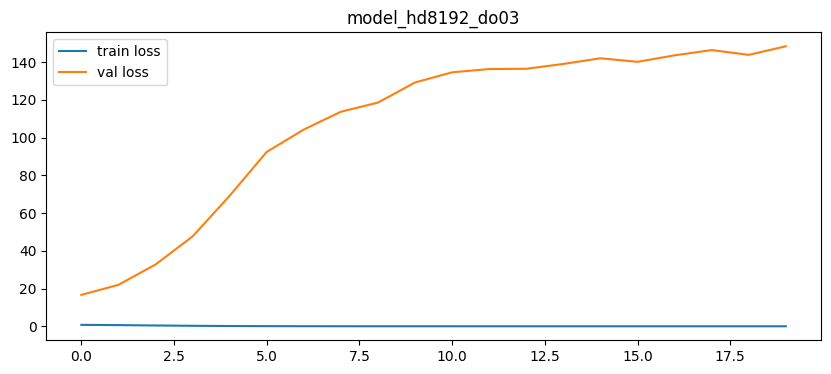

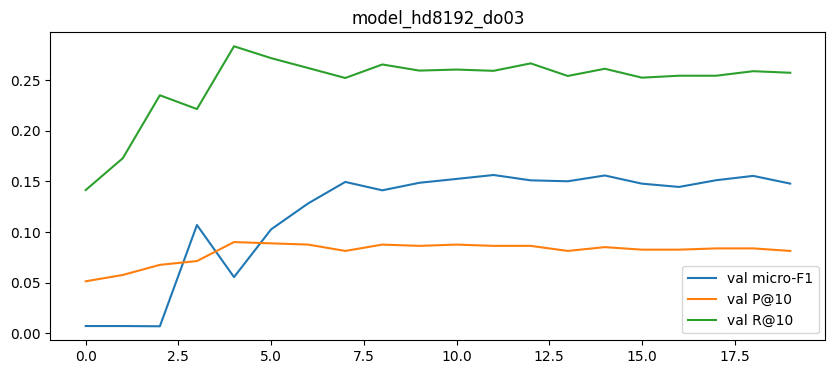

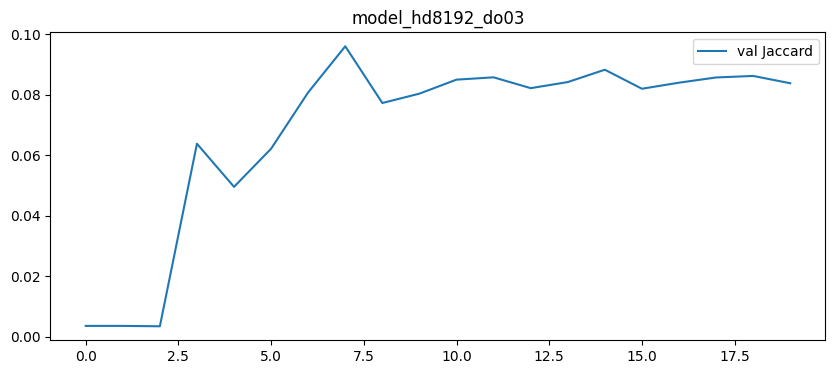


=== TEST ===
loss 153.3830 | micro-F1 0.1225 (P 0.1055 R 0.1462) | Jacc 0.0560 | P@10 0.0700 | R@10 0.1698


In [86]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)

For the last model the micro-F1 was relatively high but the model suffers from overfitting. Hence, I decided to manipulate dropout values


===== TRAINING model_hd8192_do04 (hd=8192, do=0.4) =====


100%|██████████| 10/10 [00:01<00:00,  6.97it/s]


Epoch 01/20 | train loss 0.7569 | val loss 16.7539 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0563 | R@10 0.1762


100%|██████████| 10/10 [00:02<00:00,  4.98it/s]


Epoch 02/20 | train loss 0.6223 | val loss 21.8493 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0663 | R@10 0.2072


...

Epoch 18/20 | train loss 0.0076 | val loss 140.2556 | val micro-F1 0.1594 (P 0.1392 R 0.1863) | Jacc 0.0917 | P@10 0.0875 | R@10 0.2588


100%|██████████| 10/10 [00:01<00:00,  6.17it/s]


Epoch 19/20 | train loss 0.0071 | val loss 142.4479 | val micro-F1 0.1617 (P 0.1429 R 0.1863) | Jacc 0.0902 | P@10 0.0863 | R@10 0.2596


100%|██████████| 10/10 [00:01<00:00,  5.65it/s]


Epoch 20/20 | train loss 0.0067 | val loss 138.7908 | val micro-F1 0.1517 (P 0.1279 R 0.1863) | Jacc 0.0888 | P@10 0.0825 | R@10 0.2522


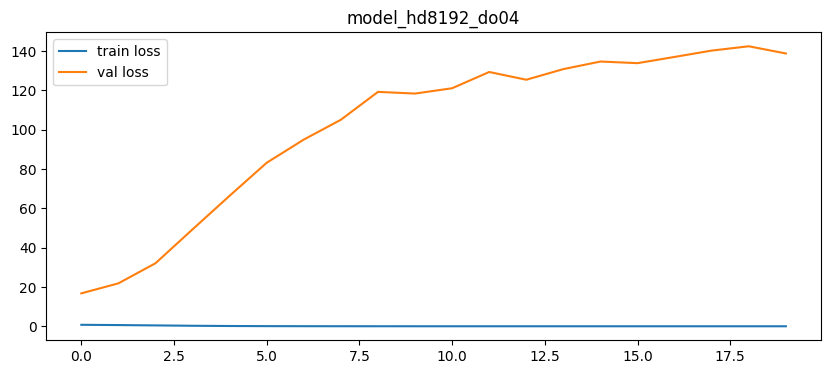

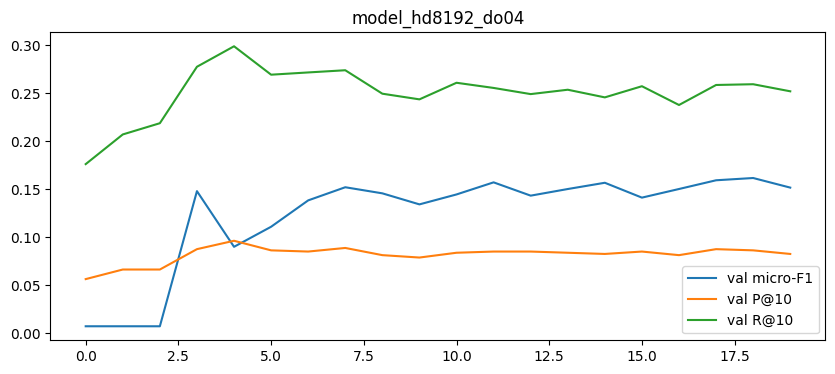

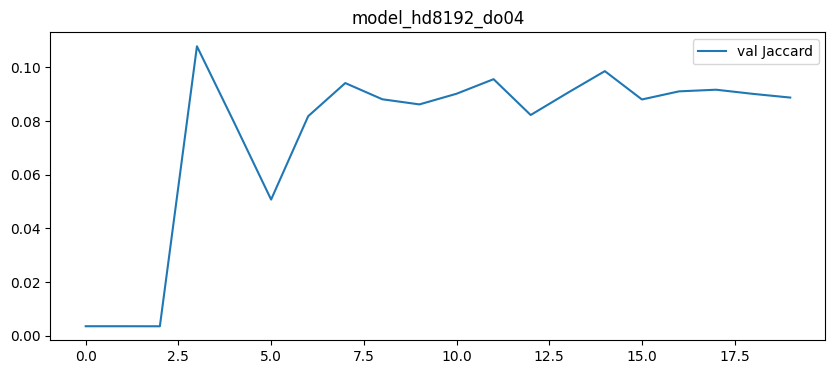


=== TEST ===
loss 167.3987 | micro-F1 0.1248 (P 0.1144 R 0.1374) | Jacc 0.0608 | P@10 0.0713 | R@10 0.1749


In [87]:
test_hiperparameters(hidden_dim=8192, dropout=0.4, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do05 (hd=8192, do=0.5) =====


100%|██████████| 10/10 [00:01<00:00,  5.69it/s]


Epoch 01/20 | train loss 0.7694 | val loss 16.7700 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0550 | R@10 0.1977


100%|██████████| 10/10 [00:02<00:00,  3.83it/s]


Epoch 02/20 | train loss 0.6340 | val loss 21.5946 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0563 | R@10 0.1967


...

Epoch 18/20 | train loss 0.0084 | val loss 141.7551 | val micro-F1 0.1565 (P 0.1348 R 0.1863) | Jacc 0.0960 | P@10 0.0875 | R@10 0.2598


100%|██████████| 10/10 [00:02<00:00,  4.36it/s]


Epoch 19/20 | train loss 0.0081 | val loss 141.6409 | val micro-F1 0.1621 (P 0.1400 R 0.1925) | Jacc 0.0994 | P@10 0.0863 | R@10 0.2565


100%|██████████| 10/10 [00:01<00:00,  7.02it/s]


Epoch 20/20 | train loss 0.0076 | val loss 144.4002 | val micro-F1 0.1559 (P 0.1374 R 0.1801) | Jacc 0.0935 | P@10 0.0838 | R@10 0.2499


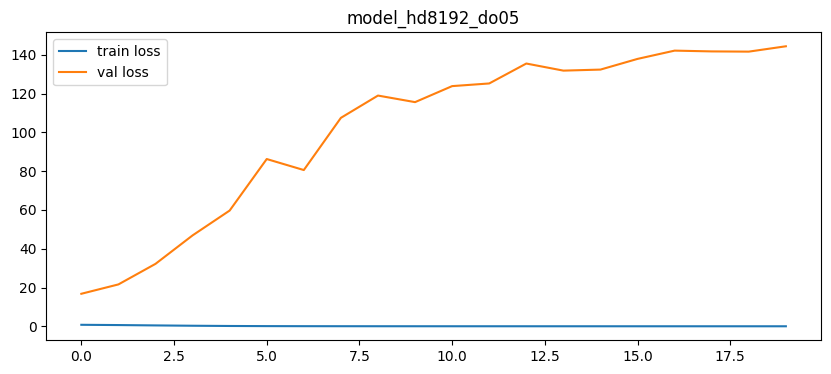

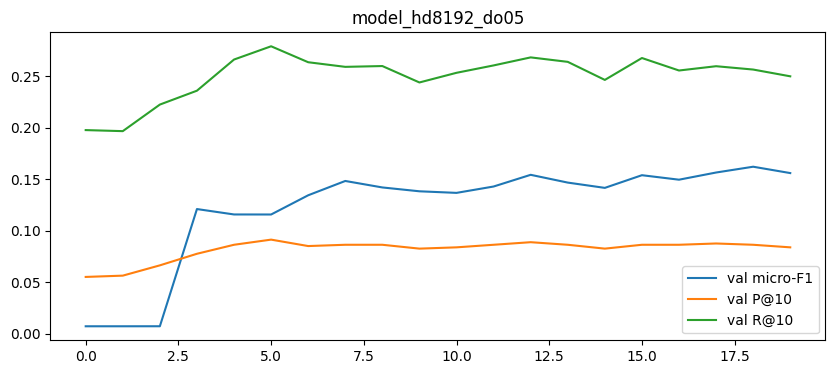

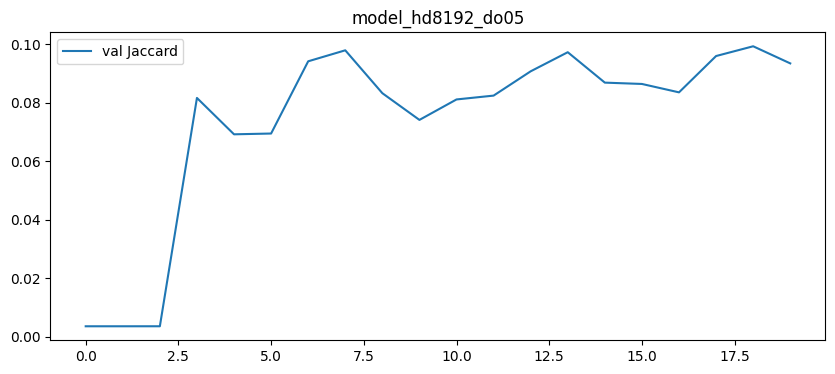


=== TEST ===
loss 159.9058 | micro-F1 0.1241 (P 0.1094 R 0.1433) | Jacc 0.0578 | P@10 0.0663 | R@10 0.1528


In [88]:
test_hiperparameters(hidden_dim=8192, dropout=0.5, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do06 (hd=8192, do=0.6) =====


100%|██████████| 10/10 [00:01<00:00,  5.31it/s]


Epoch 01/20 | train loss 0.7768 | val loss 16.8019 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0638 | R@10 0.1754


100%|██████████| 10/10 [00:02<00:00,  4.65it/s]


Epoch 02/20 | train loss 0.6389 | val loss 21.7363 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0650 | R@10 0.1995


...

Epoch 18/20 | train loss 0.0105 | val loss 134.6539 | val micro-F1 0.1363 (P 0.1085 R 0.1832) | Jacc 0.0772 | P@10 0.0813 | R@10 0.2563


100%|██████████| 10/10 [00:01<00:00,  5.97it/s]


Epoch 19/20 | train loss 0.0095 | val loss 141.6425 | val micro-F1 0.1411 (P 0.1186 R 0.1739) | Jacc 0.0790 | P@10 0.0838 | R@10 0.2588


100%|██████████| 10/10 [00:02<00:00,  4.83it/s]


Epoch 20/20 | train loss 0.0095 | val loss 145.3096 | val micro-F1 0.1452 (P 0.1280 R 0.1677) | Jacc 0.0768 | P@10 0.0813 | R@10 0.2455


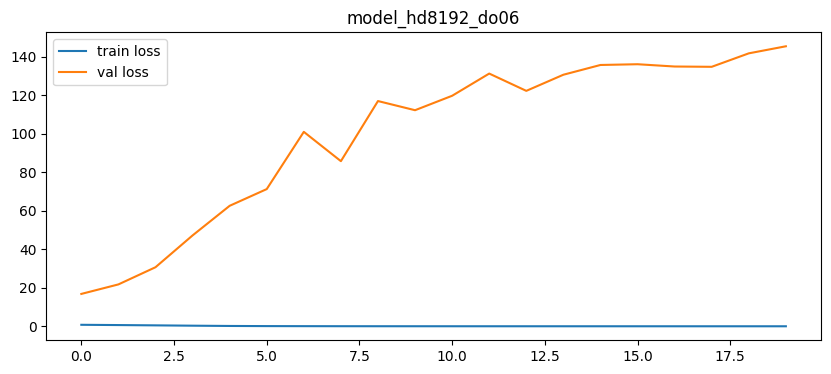

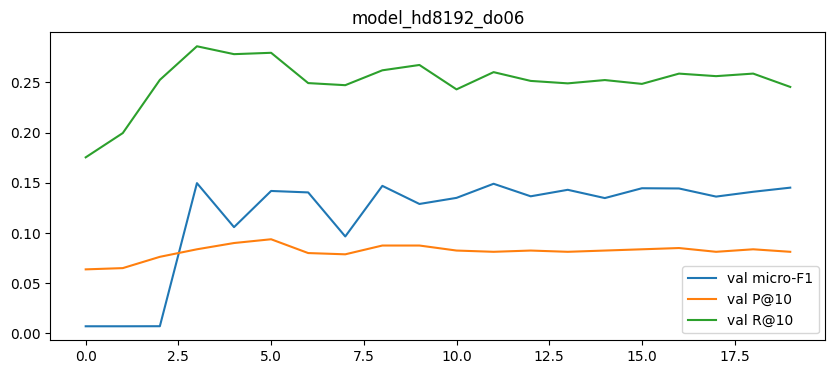

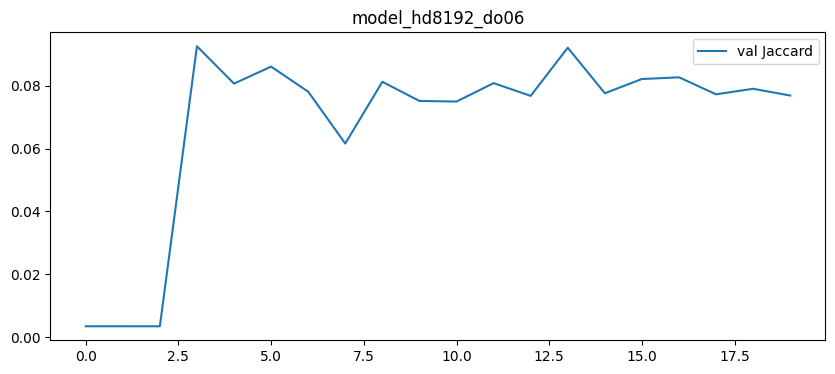


=== TEST ===
loss 53.1294 | micro-F1 0.0989 (P 0.1049 R 0.0936) | Jacc 0.0528 | P@10 0.0725 | R@10 0.1695


In [89]:
test_hiperparameters(hidden_dim=8192, dropout=0.6, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do07 (hd=8192, do=0.7) =====


100%|██████████| 10/10 [00:01<00:00,  5.94it/s]


Epoch 01/20 | train loss 0.8083 | val loss 16.6861 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0500 | R@10 0.1905


100%|██████████| 10/10 [00:01<00:00,  5.93it/s]


Epoch 02/20 | train loss 0.6851 | val loss 20.8898 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0738 | R@10 0.2433


...

Epoch 18/20 | train loss 0.0134 | val loss 135.1800 | val micro-F1 0.1549 (P 0.1245 R 0.2050) | Jacc 0.0978 | P@10 0.0863 | R@10 0.2595


100%|██████████| 10/10 [00:01<00:00,  5.86it/s]


Epoch 19/20 | train loss 0.0130 | val loss 138.3197 | val micro-F1 0.1475 (P 0.1184 R 0.1957) | Jacc 0.0822 | P@10 0.0850 | R@10 0.2595


100%|██████████| 10/10 [00:01<00:00,  5.67it/s]


Epoch 20/20 | train loss 0.0121 | val loss 139.3627 | val micro-F1 0.1481 (P 0.1191 R 0.1957) | Jacc 0.0917 | P@10 0.0850 | R@10 0.2598


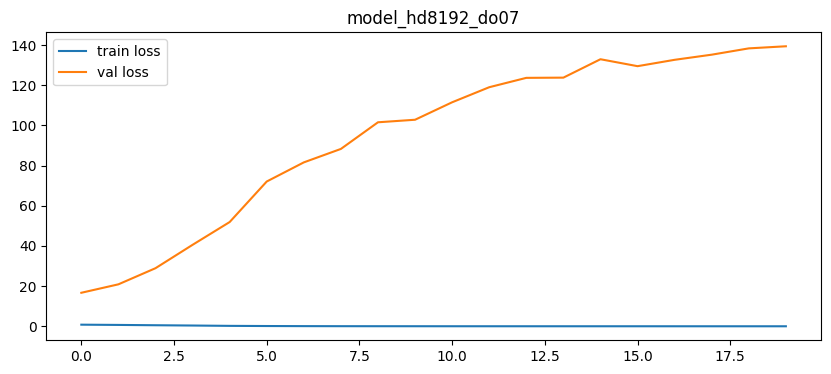

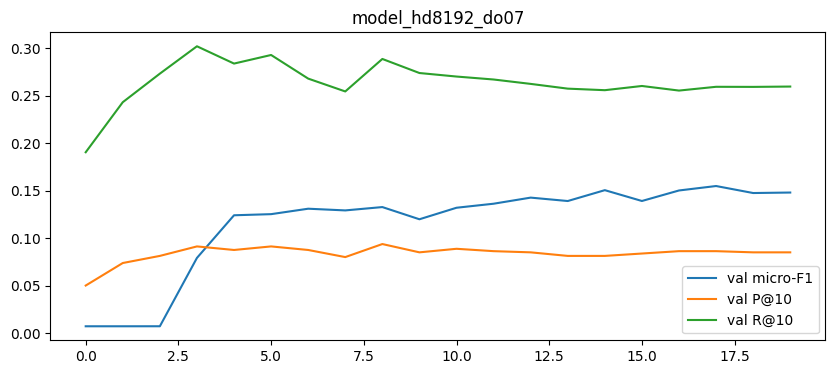

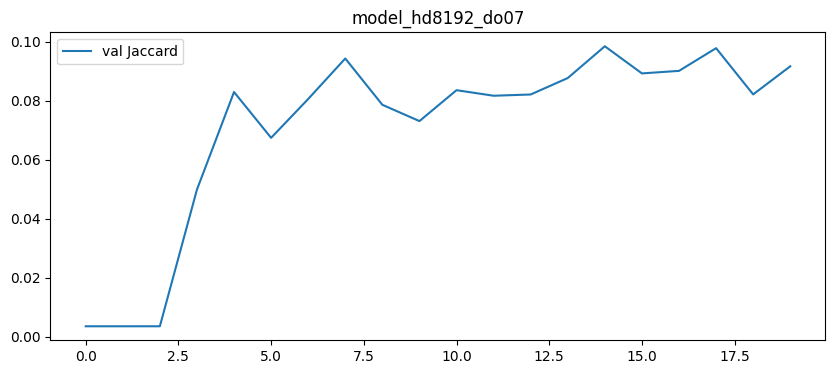


=== TEST ===
loss 161.4001 | micro-F1 0.1200 (P 0.0980 R 0.1550) | Jacc 0.0497 | P@10 0.0688 | R@10 0.1732


In [90]:
test_hiperparameters(hidden_dim=8192, dropout=0.7, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)

Increase of dropout did not enhance micro-F1, let's decrease it


===== TRAINING model_hd8192_do02 (hd=8192, do=0.2) =====


100%|██████████| 10/10 [00:01<00:00,  5.65it/s]


Epoch 01/20 | train loss 0.7557 | val loss 16.6251 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0575 | R@10 0.1567


100%|██████████| 10/10 [00:01<00:00,  5.64it/s]


Epoch 02/20 | train loss 0.6306 | val loss 21.9514 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0713 | R@10 0.2408


...

Epoch 18/20 | train loss 0.0058 | val loss 143.2371 | val micro-F1 0.1516 (P 0.1309 R 0.1801) | Jacc 0.0937 | P@10 0.0838 | R@10 0.2593


100%|██████████| 10/10 [00:01<00:00,  5.72it/s]


Epoch 19/20 | train loss 0.0058 | val loss 148.9103 | val micro-F1 0.1532 (P 0.1389 R 0.1708) | Jacc 0.0970 | P@10 0.0875 | R@10 0.2648


100%|██████████| 10/10 [00:02<00:00,  4.66it/s]


Epoch 20/20 | train loss 0.0054 | val loss 146.0108 | val micro-F1 0.1497 (P 0.1280 R 0.1801) | Jacc 0.0951 | P@10 0.0875 | R@10 0.2617


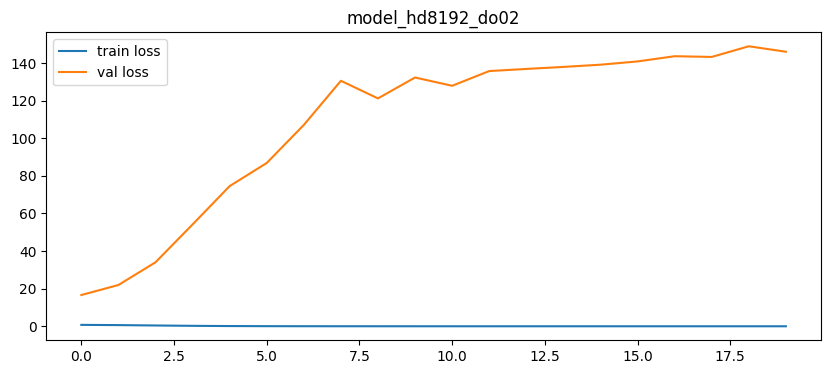

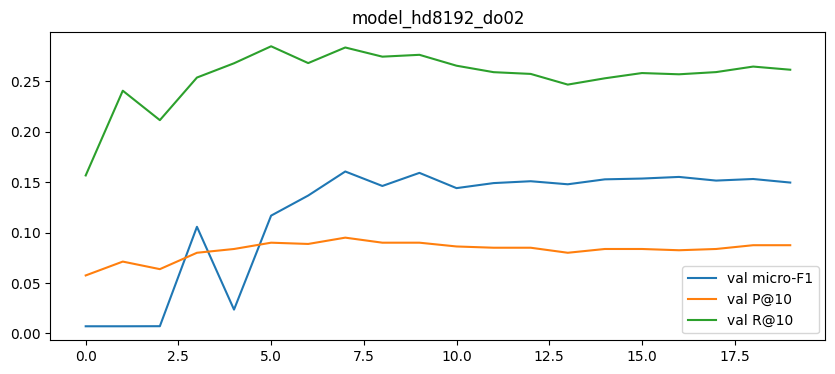

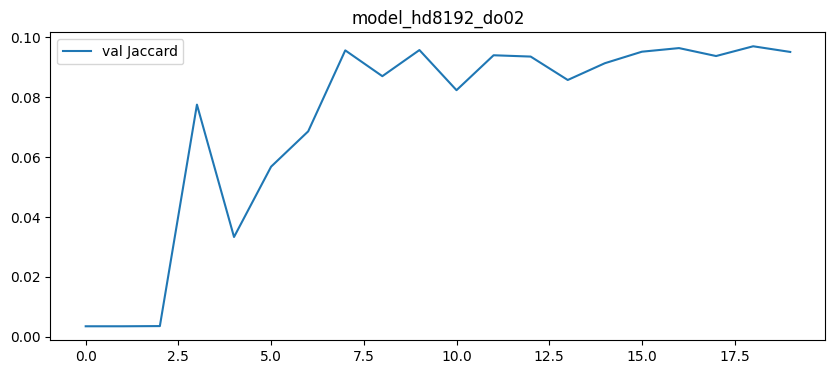


=== TEST ===
loss 149.9401 | micro-F1 0.1213 (P 0.1296 R 0.1140) | Jacc 0.0534 | P@10 0.0688 | R@10 0.1688


In [91]:
test_hiperparameters(hidden_dim=8192, dropout=0.2, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do01 (hd=8192, do=0.1) =====


100%|██████████| 10/10 [00:01<00:00,  6.31it/s]


Epoch 01/20 | train loss 0.7621 | val loss 16.3743 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0588 | R@10 0.1856


100%|██████████| 10/10 [00:01<00:00,  6.76it/s]


Epoch 02/20 | train loss 0.6444 | val loss 21.7502 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0625 | R@10 0.1927


...

Epoch 18/20 | train loss 0.0057 | val loss 150.7865 | val micro-F1 0.1583 (P 0.1411 R 0.1801) | Jacc 0.0876 | P@10 0.0837 | R@10 0.2382


100%|██████████| 10/10 [00:02<00:00,  3.89it/s]


Epoch 19/20 | train loss 0.0052 | val loss 152.8579 | val micro-F1 0.1600 (P 0.1439 R 0.1801) | Jacc 0.0924 | P@10 0.0838 | R@10 0.2389


100%|██████████| 10/10 [00:02<00:00,  3.45it/s]


Epoch 20/20 | train loss 0.0050 | val loss 155.1684 | val micro-F1 0.1613 (P 0.1461 R 0.1801) | Jacc 0.0923 | P@10 0.0850 | R@10 0.2500


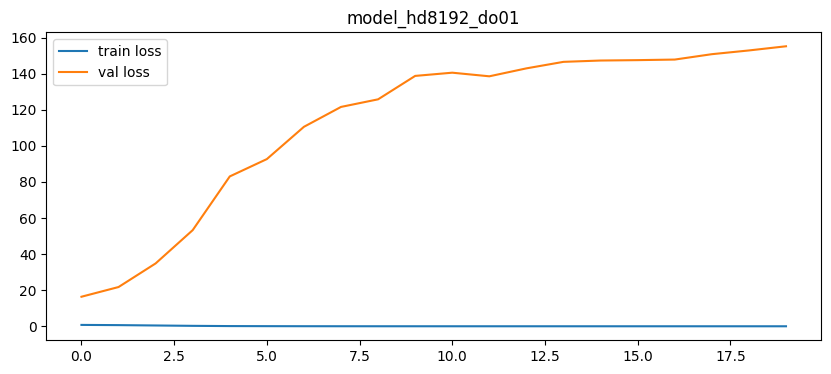

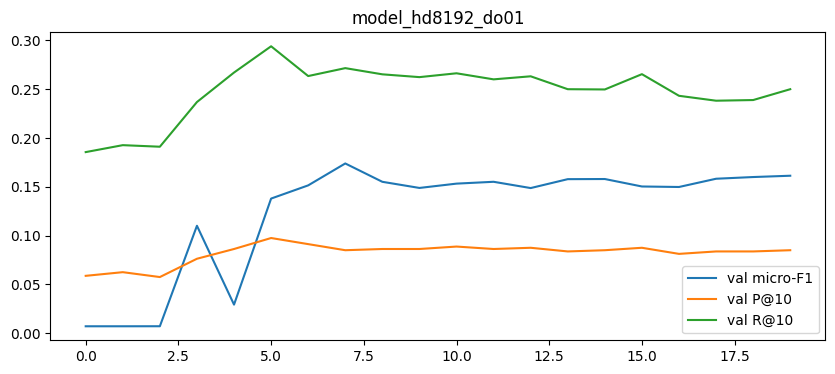

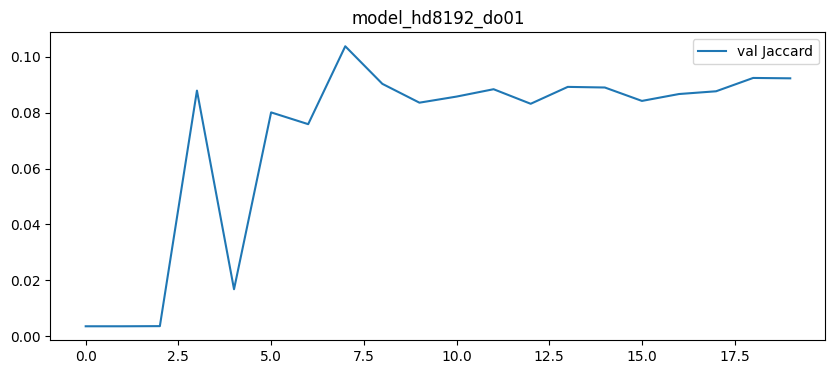


=== TEST ===
loss 139.2296 | micro-F1 0.1146 (P 0.0955 R 0.1433) | Jacc 0.0534 | P@10 0.0663 | R@10 0.1667


In [92]:
test_hiperparameters(hidden_dim=8192, dropout=0.1, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)

It turned out that the value of dropout barely affected the micro-F1 and we can pick dropout=0.3

Let us test various weight decays


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.69it/s]


Epoch 01/20 | train loss 0.7499 | val loss 16.8060 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0500 | R@10 0.1718


100%|██████████| 10/10 [00:02<00:00,  3.39it/s]


Epoch 02/20 | train loss 0.6209 | val loss 22.1011 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0588 | R@10 0.2037


...

Epoch 18/20 | train loss 0.0069 | val loss 145.9672 | val micro-F1 0.1534 (P 0.1336 R 0.1801) | Jacc 0.0841 | P@10 0.0850 | R@10 0.2591


100%|██████████| 10/10 [00:02<00:00,  3.78it/s]


Epoch 19/20 | train loss 0.0063 | val loss 145.6135 | val micro-F1 0.1446 (P 0.1194 R 0.1832) | Jacc 0.0834 | P@10 0.0863 | R@10 0.2583


100%|██████████| 10/10 [00:01<00:00,  5.51it/s]


Epoch 20/20 | train loss 0.0059 | val loss 148.3608 | val micro-F1 0.1471 (P 0.1258 R 0.1770) | Jacc 0.0857 | P@10 0.0863 | R@10 0.2633


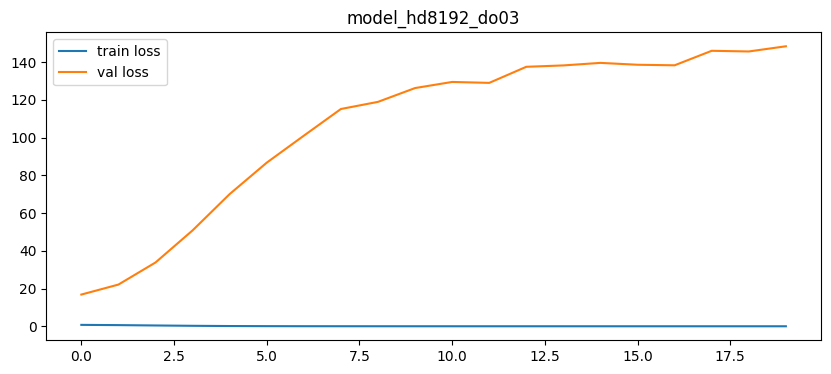

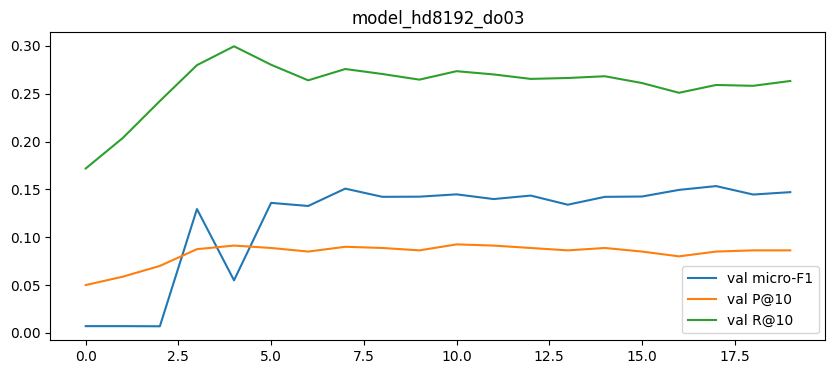

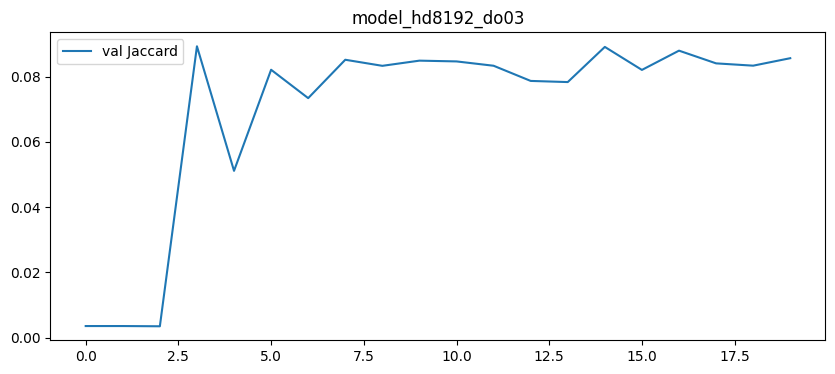


=== TEST ===
loss 169.8869 | micro-F1 0.1202 (P 0.1128 R 0.1287) | Jacc 0.0612 | P@10 0.0688 | R@10 0.1711


In [93]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-3, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:02<00:00,  4.55it/s]


Epoch 01/20 | train loss 0.7565 | val loss 16.6685 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0488 | R@10 0.1476


100%|██████████| 10/10 [00:02<00:00,  4.76it/s]


Epoch 02/20 | train loss 0.6271 | val loss 22.2734 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0675 | R@10 0.2146


...

Epoch 18/20 | train loss 0.0072 | val loss 149.7349 | val micro-F1 0.1560 (P 0.1342 R 0.1863) | Jacc 0.0928 | P@10 0.0838 | R@10 0.2443


100%|██████████| 10/10 [00:02<00:00,  3.88it/s]


Epoch 19/20 | train loss 0.0063 | val loss 150.4450 | val micro-F1 0.1558 (P 0.1323 R 0.1894) | Jacc 0.0920 | P@10 0.0887 | R@10 0.2576


100%|██████████| 10/10 [00:02<00:00,  4.03it/s]


Epoch 20/20 | train loss 0.0061 | val loss 154.4453 | val micro-F1 0.1508 (P 0.1298 R 0.1801) | Jacc 0.0867 | P@10 0.0838 | R@10 0.2475


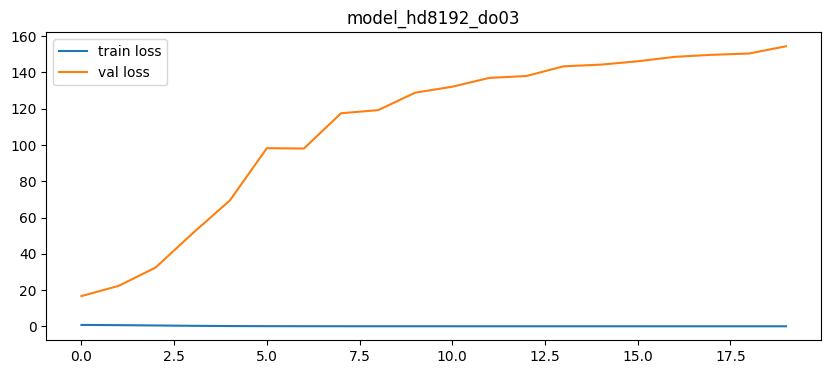

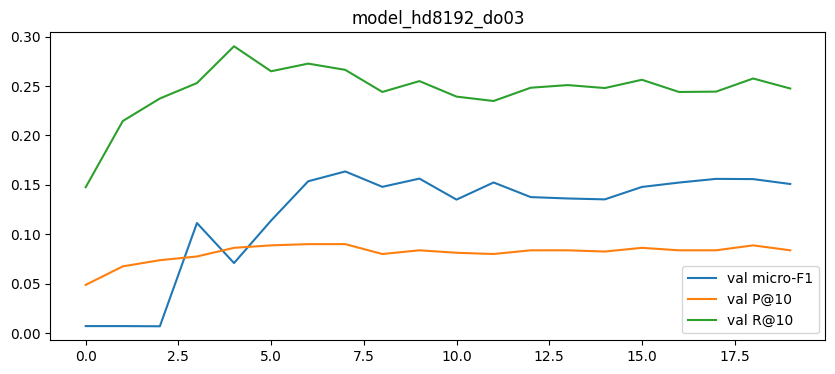

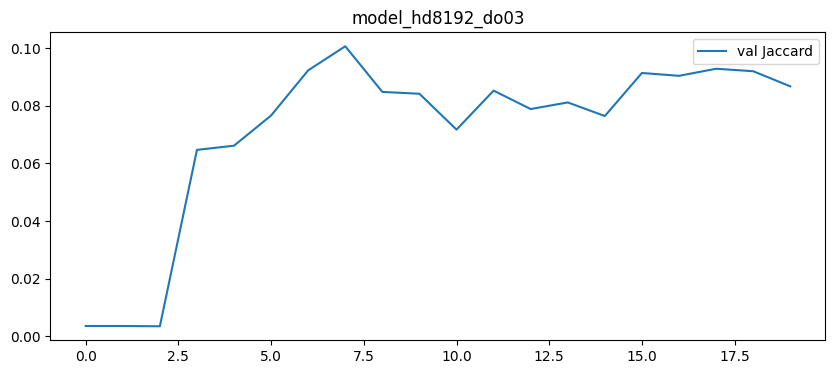


=== TEST ===
loss 131.7269 | micro-F1 0.1145 (P 0.1096 R 0.1199) | Jacc 0.0547 | P@10 0.0712 | R@10 0.1739


In [94]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=3e-3, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.07it/s]


Epoch 01/20 | train loss 0.7546 | val loss 16.7019 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0550 | R@10 0.1678


100%|██████████| 10/10 [00:02<00:00,  4.98it/s]


Epoch 02/20 | train loss 0.6231 | val loss 22.1269 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0638 | R@10 0.1786


...

Epoch 18/20 | train loss 0.0067 | val loss 141.5512 | val micro-F1 0.1620 (P 0.1368 R 0.1988) | Jacc 0.0951 | P@10 0.0875 | R@10 0.2662


100%|██████████| 10/10 [00:01<00:00,  5.09it/s]


Epoch 19/20 | train loss 0.0069 | val loss 146.0717 | val micro-F1 0.1570 (P 0.1341 R 0.1894) | Jacc 0.0888 | P@10 0.0863 | R@10 0.2610


100%|██████████| 10/10 [00:02<00:00,  4.94it/s]


Epoch 20/20 | train loss 0.0064 | val loss 148.3489 | val micro-F1 0.1644 (P 0.1452 R 0.1894) | Jacc 0.0969 | P@10 0.0863 | R@10 0.2580


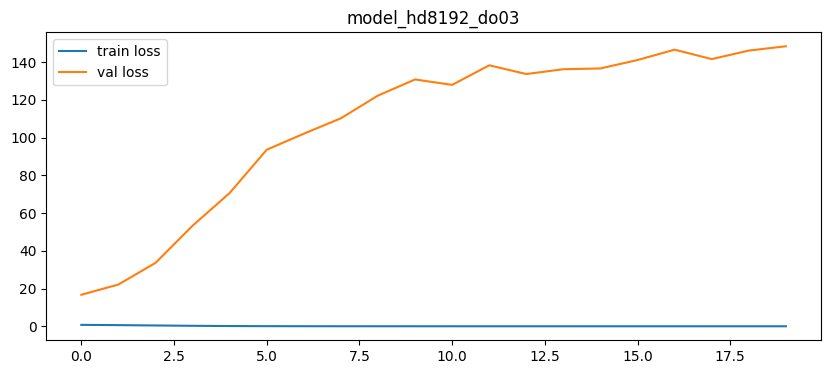

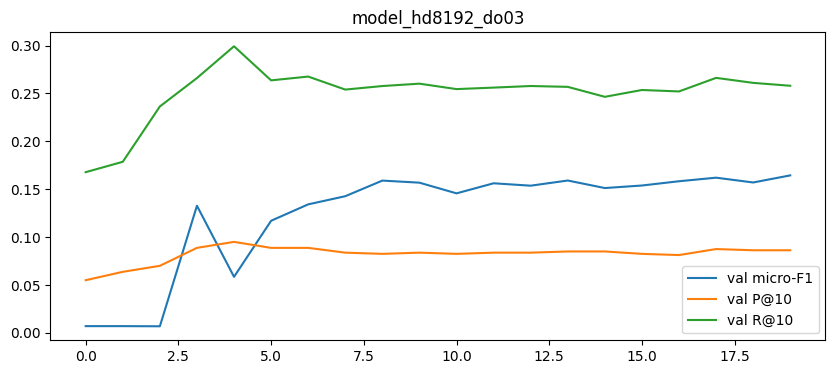

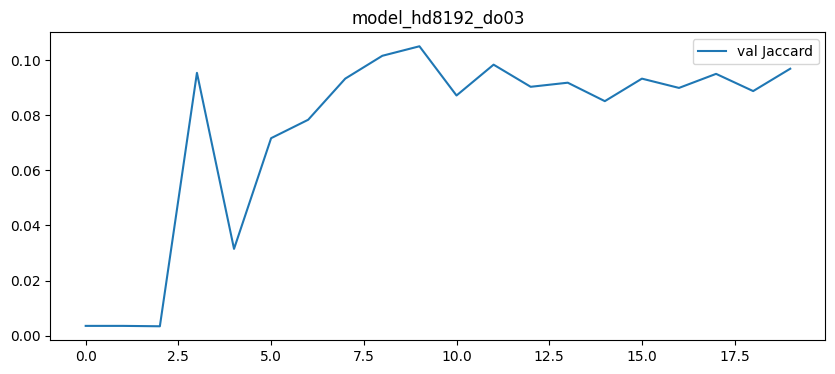


=== TEST ===
loss 165.7263 | micro-F1 0.1189 (P 0.1065 R 0.1345) | Jacc 0.0515 | P@10 0.0750 | R@10 0.1877


In [95]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=3e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:02<00:00,  3.42it/s]


Epoch 01/20 | train loss 0.7579 | val loss 16.7071 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0625 | R@10 0.1942


100%|██████████| 10/10 [00:02<00:00,  4.89it/s]


Epoch 02/20 | train loss 0.6317 | val loss 21.9206 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0700 | R@10 0.2061


...

Epoch 18/20 | train loss 0.0067 | val loss 142.7246 | val micro-F1 0.1549 (P 0.1358 R 0.1801) | Jacc 0.0890 | P@10 0.0838 | R@10 0.2508


100%|██████████| 10/10 [00:02<00:00,  3.68it/s]


Epoch 19/20 | train loss 0.0066 | val loss 142.2870 | val micro-F1 0.1470 (P 0.1273 R 0.1739) | Jacc 0.0837 | P@10 0.0850 | R@10 0.2601


100%|██████████| 10/10 [00:01<00:00,  5.10it/s]


Epoch 20/20 | train loss 0.0064 | val loss 144.4713 | val micro-F1 0.1510 (P 0.1300 R 0.1801) | Jacc 0.0853 | P@10 0.0813 | R@10 0.2544


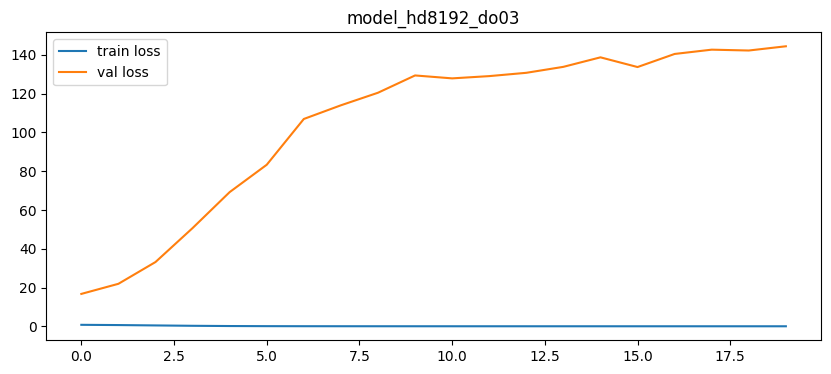

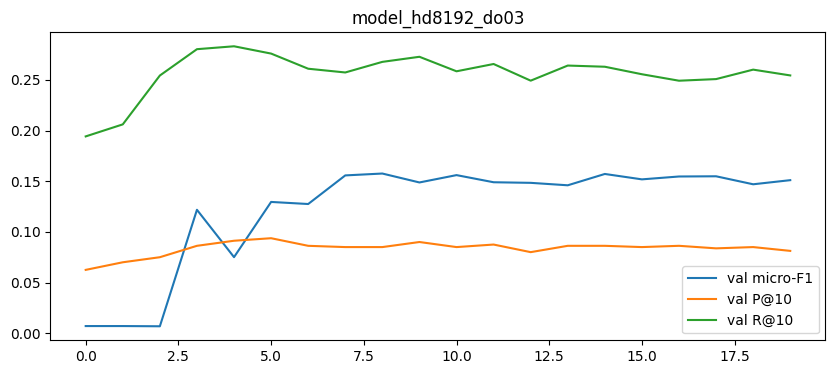

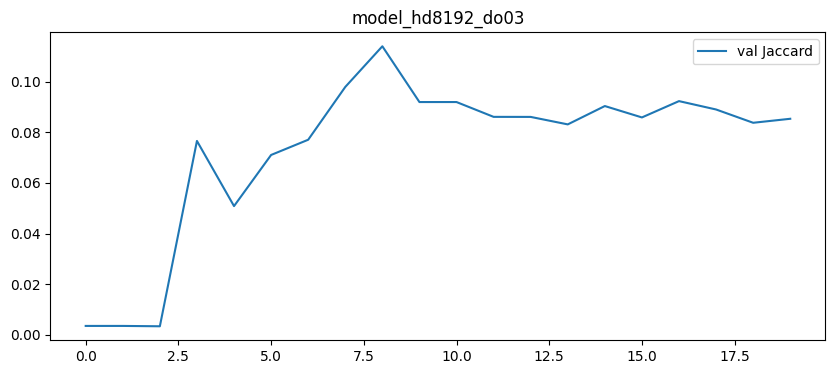


=== TEST ===
loss 136.2493 | micro-F1 0.1210 (P 0.1018 R 0.1491) | Jacc 0.0538 | P@10 0.0700 | R@10 0.1722


In [96]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-1, n_epochs=20, threshold=0.2, k_at=10)

Almost no effect of weight decay.

We can test decreasing learning rate


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:02<00:00,  4.98it/s]


Epoch 01/20 | train loss 0.7600 | val loss 16.7699 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0437 | R@10 0.1275


100%|██████████| 10/10 [00:02<00:00,  3.64it/s]


Epoch 02/20 | train loss 0.6234 | val loss 21.9938 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0375 | R@10 0.1149


...

Epoch 18/20 | train loss 0.0068 | val loss 142.8029 | val micro-F1 0.1560 (P 0.1342 R 0.1863) | Jacc 0.0858 | P@10 0.0875 | R@10 0.2653


100%|██████████| 10/10 [00:01<00:00,  5.26it/s]


Epoch 19/20 | train loss 0.0064 | val loss 143.3256 | val micro-F1 0.1545 (P 0.1335 R 0.1832) | Jacc 0.0938 | P@10 0.0925 | R@10 0.2765


100%|██████████| 10/10 [00:01<00:00,  5.28it/s]


Epoch 20/20 | train loss 0.0065 | val loss 144.5481 | val micro-F1 0.1505 (P 0.1277 R 0.1832) | Jacc 0.0950 | P@10 0.0875 | R@10 0.2693


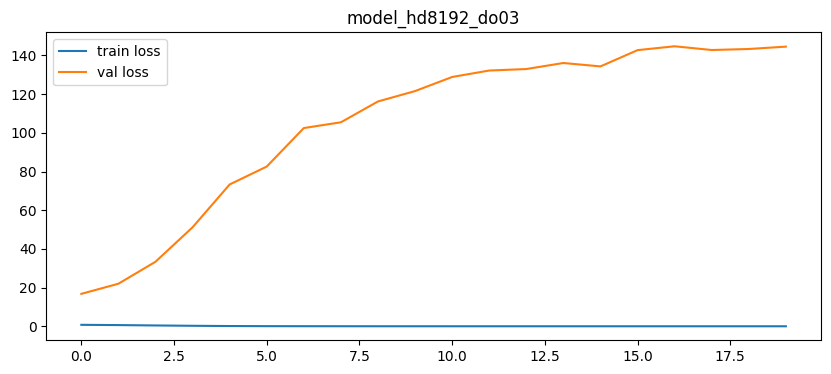

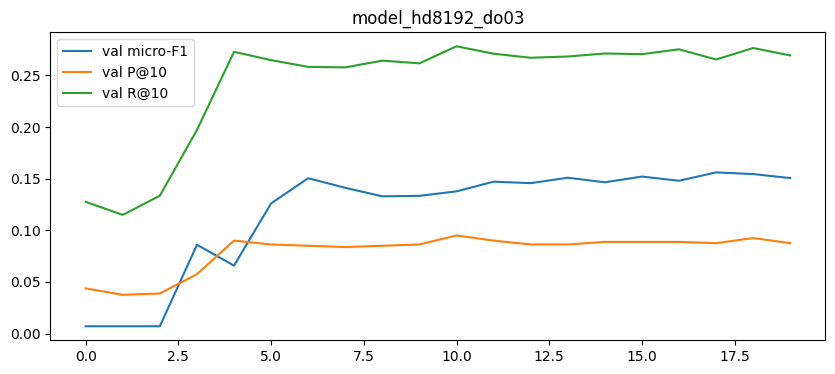

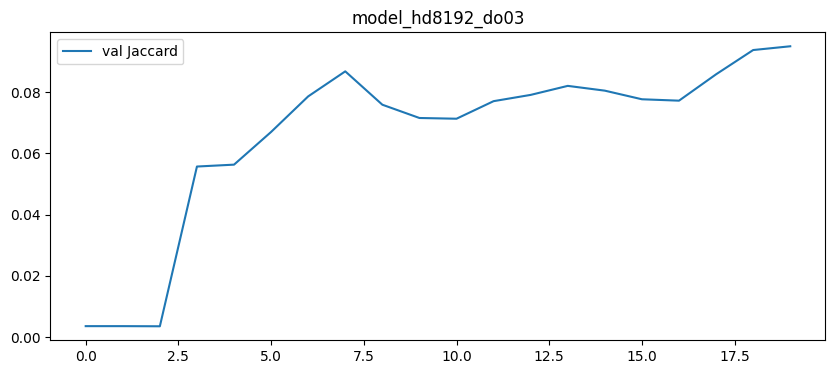


=== TEST ===
loss 168.2988 | micro-F1 0.1313 (P 0.1172 R 0.1491) | Jacc 0.0631 | P@10 0.0800 | R@10 0.1976


In [97]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.26it/s]


Epoch 01/20 | train loss 0.7571 | val loss 15.9968 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0600 | R@10 0.1862


100%|██████████| 10/10 [00:01<00:00,  5.17it/s]


Epoch 02/20 | train loss 0.6612 | val loss 19.2412 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0712 | R@10 0.2146


...

Epoch 18/20 | train loss 0.0084 | val loss 131.2114 | val micro-F1 0.1558 (P 0.1323 R 0.1894) | Jacc 0.0865 | P@10 0.0913 | R@10 0.2678


100%|██████████| 10/10 [00:01<00:00,  5.49it/s]


Epoch 19/20 | train loss 0.0079 | val loss 133.0055 | val micro-F1 0.1534 (P 0.1320 R 0.1832) | Jacc 0.0889 | P@10 0.0887 | R@10 0.2628


100%|██████████| 10/10 [00:02<00:00,  4.58it/s]


Epoch 20/20 | train loss 0.0071 | val loss 134.2936 | val micro-F1 0.1500 (P 0.1301 R 0.1770) | Jacc 0.0893 | P@10 0.0825 | R@10 0.2515


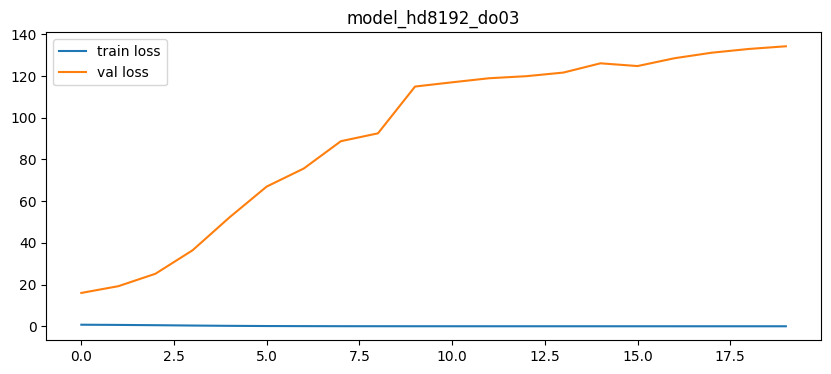

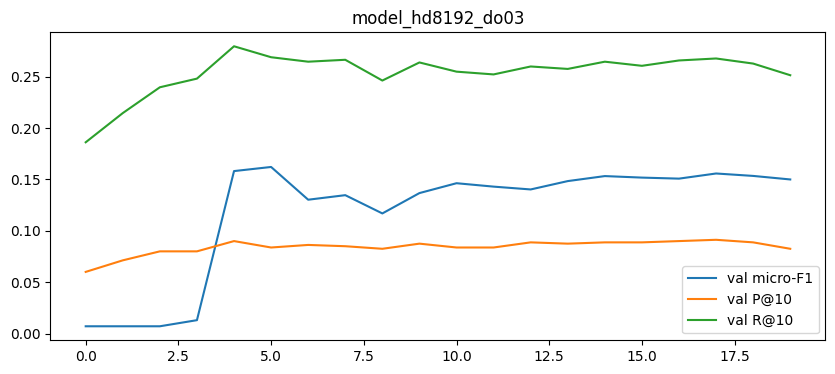

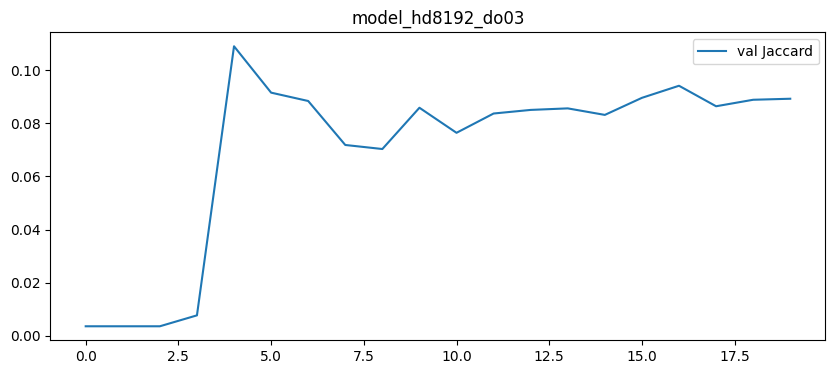


=== TEST ===
loss 74.9232 | micro-F1 0.1110 (P 0.1033 R 0.1199) | Jacc 0.0569 | P@10 0.0712 | R@10 0.1696


In [98]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=8e-4, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.29it/s]


Epoch 01/20 | train loss 0.7562 | val loss 15.5252 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0613 | R@10 0.2028


100%|██████████| 10/10 [00:01<00:00,  5.31it/s]


Epoch 02/20 | train loss 0.6811 | val loss 17.0752 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0750 | R@10 0.2310


...

Epoch 18/20 | train loss 0.0113 | val loss 118.6925 | val micro-F1 0.1560 (P 0.1260 R 0.2050) | Jacc 0.0977 | P@10 0.0887 | R@10 0.2686


100%|██████████| 10/10 [00:01<00:00,  5.54it/s]


Epoch 19/20 | train loss 0.0105 | val loss 121.5288 | val micro-F1 0.1626 (P 0.1335 R 0.2081) | Jacc 0.1006 | P@10 0.0900 | R@10 0.2738


100%|██████████| 10/10 [00:01<00:00,  5.20it/s]


Epoch 20/20 | train loss 0.0101 | val loss 123.9006 | val micro-F1 0.1694 (P 0.1429 R 0.2081) | Jacc 0.1057 | P@10 0.0913 | R@10 0.2793


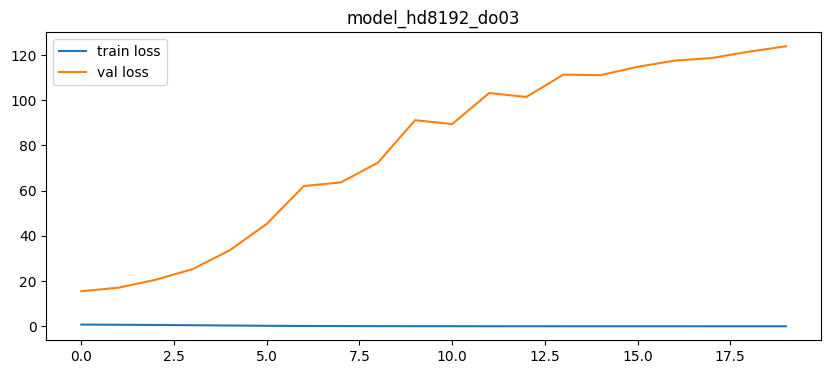

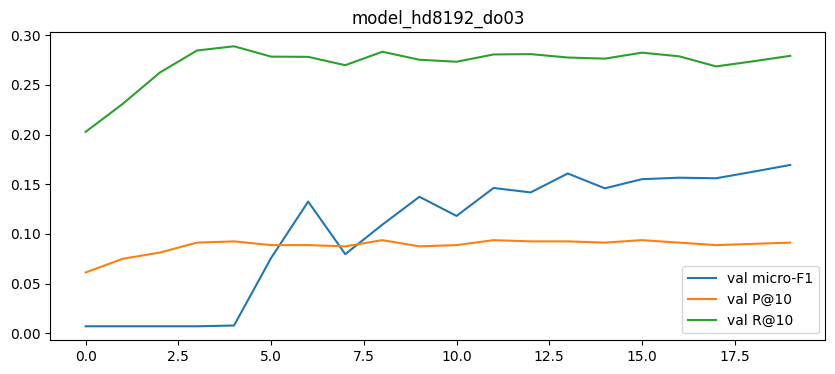

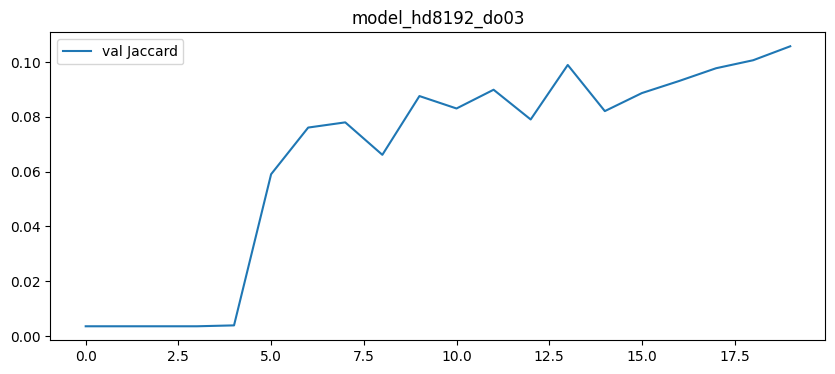


=== TEST ===
loss 140.7681 | micro-F1 0.1295 (P 0.1098 R 0.1579) | Jacc 0.0597 | P@10 0.0788 | R@10 0.1932


In [99]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=6e-4, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:02<00:00,  4.61it/s]


Epoch 01/20 | train loss 0.7564 | val loss 15.2404 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0563 | R@10 0.1584


100%|██████████| 10/10 [00:01<00:00,  5.58it/s]


Epoch 02/20 | train loss 0.7053 | val loss 15.9285 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0762 | R@10 0.2137


...

Epoch 18/20 | train loss 0.0244 | val loss 92.1161 | val micro-F1 0.1325 (P 0.0926 R 0.2329) | Jacc 0.0772 | P@10 0.0875 | R@10 0.2556


100%|██████████| 10/10 [00:02<00:00,  4.74it/s]


Epoch 19/20 | train loss 0.0217 | val loss 98.9539 | val micro-F1 0.1393 (P 0.1025 R 0.2174) | Jacc 0.0767 | P@10 0.0850 | R@10 0.2566


100%|██████████| 10/10 [00:02<00:00,  4.47it/s]


Epoch 20/20 | train loss 0.0194 | val loss 100.8611 | val micro-F1 0.1526 (P 0.1150 R 0.2267) | Jacc 0.0903 | P@10 0.0887 | R@10 0.2651


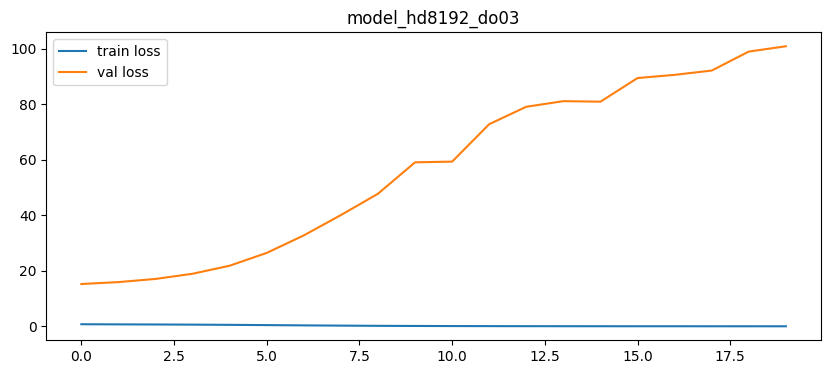

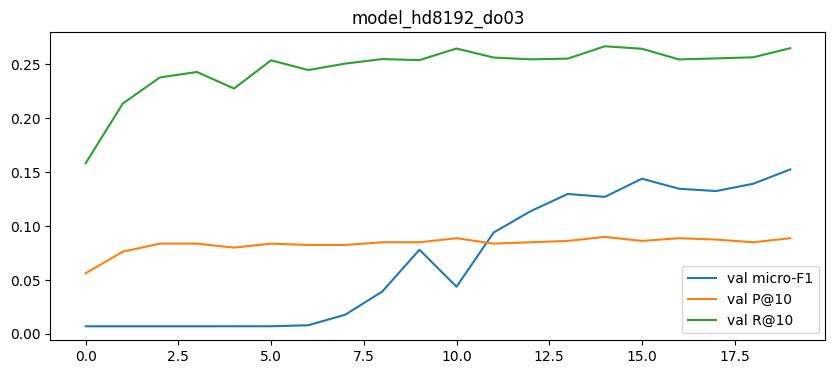

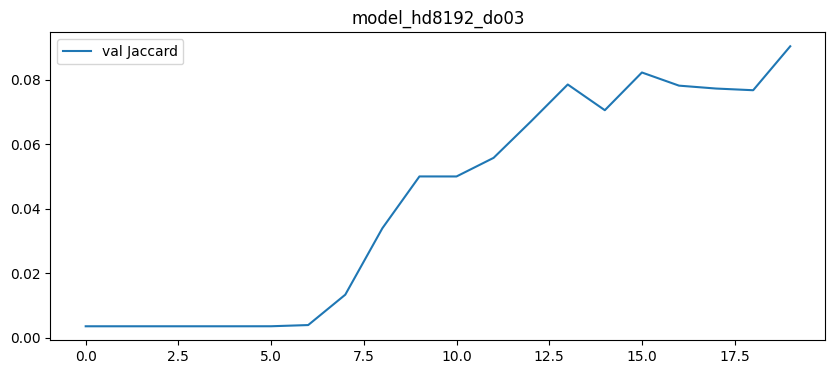


=== TEST ===
loss 113.7353 | micro-F1 0.1124 (P 0.0833 R 0.1725) | Jacc 0.0532 | P@10 0.0713 | R@10 0.1763


In [100]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=4e-4, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)

### Threshold


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.54it/s]


Epoch 01/20 | train loss 0.7548 | val loss 16.7973 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0575 | R@10 0.1669


100%|██████████| 10/10 [00:01<00:00,  6.40it/s]


Epoch 02/20 | train loss 0.6241 | val loss 22.3116 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0450 | R@10 0.1446


...

Epoch 18/20 | train loss 0.0065 | val loss 148.9212 | val micro-F1 0.1384 (P 0.1029 R 0.2112) | Jacc 0.0776 | P@10 0.0838 | R@10 0.2441


100%|██████████| 10/10 [00:01<00:00,  6.06it/s]


Epoch 19/20 | train loss 0.0064 | val loss 143.8310 | val micro-F1 0.1398 (P 0.1011 R 0.2267) | Jacc 0.0780 | P@10 0.0838 | R@10 0.2534


100%|██████████| 10/10 [00:02<00:00,  3.47it/s]


Epoch 20/20 | train loss 0.0061 | val loss 147.3089 | val micro-F1 0.1395 (P 0.1034 R 0.2143) | Jacc 0.0767 | P@10 0.0850 | R@10 0.2573


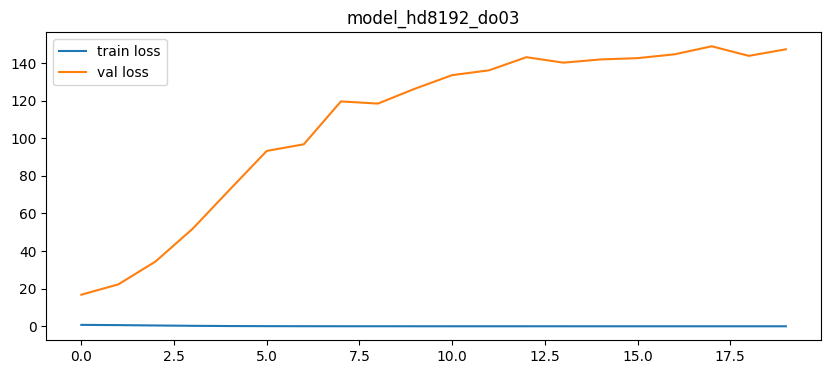

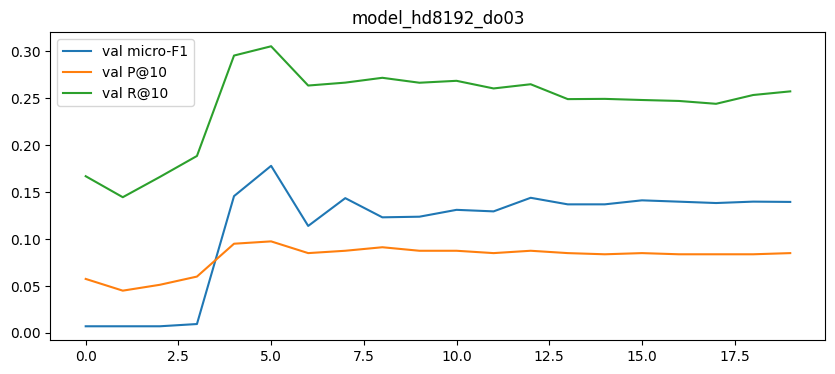

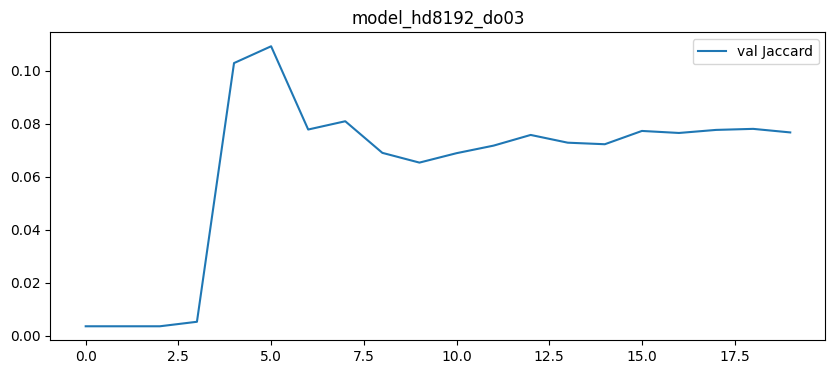


=== TEST ===
loss 103.5882 | micro-F1 0.1090 (P 0.1020 R 0.1170) | Jacc 0.0621 | P@10 0.0788 | R@10 0.1940


In [102]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.1, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.61it/s]


Epoch 01/20 | train loss 0.7583 | val loss 16.6370 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0475 | R@10 0.1458


100%|██████████| 10/10 [00:01<00:00,  5.81it/s]


Epoch 02/20 | train loss 0.6260 | val loss 21.8170 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0537 | R@10 0.1610


...

Epoch 18/20 | train loss 0.0069 | val loss 143.4410 | val micro-F1 0.1404 (P 0.1105 R 0.1925) | Jacc 0.0719 | P@10 0.0825 | R@10 0.2416


100%|██████████| 10/10 [00:01<00:00,  5.78it/s]


Epoch 19/20 | train loss 0.0066 | val loss 144.7811 | val micro-F1 0.1452 (P 0.1165 R 0.1925) | Jacc 0.0748 | P@10 0.0838 | R@10 0.2506


100%|██████████| 10/10 [00:02<00:00,  4.68it/s]


Epoch 20/20 | train loss 0.0064 | val loss 149.4060 | val micro-F1 0.1533 (P 0.1287 R 0.1894) | Jacc 0.0819 | P@10 0.0850 | R@10 0.2526


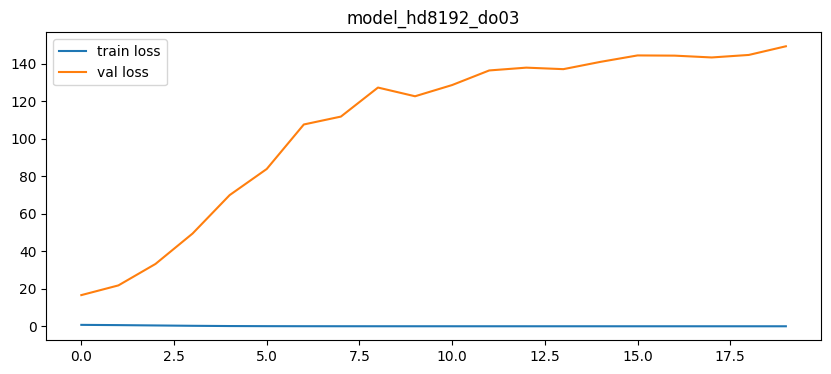

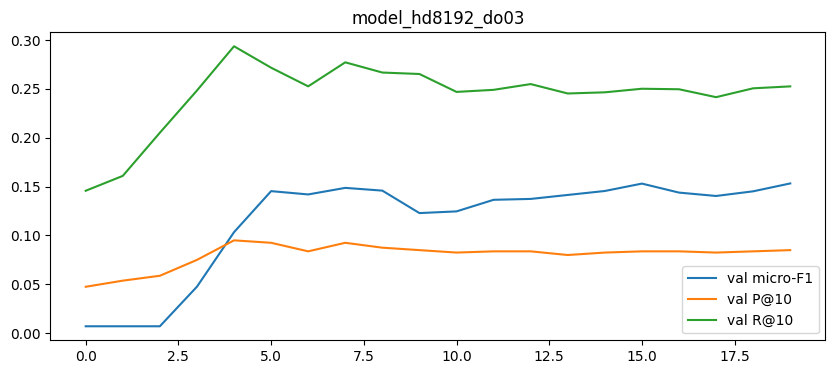

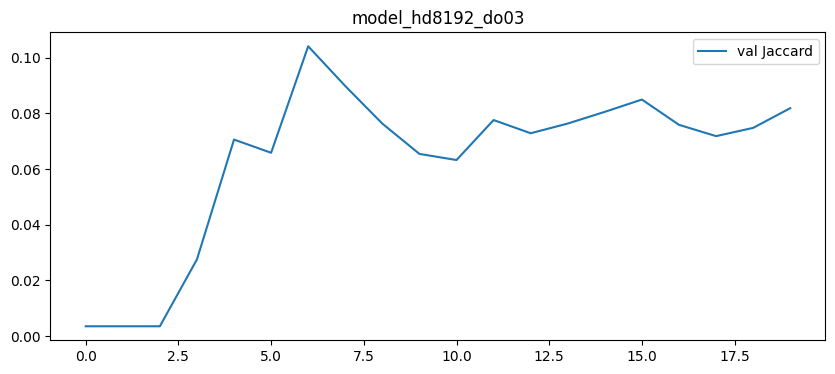


=== TEST ===
loss 169.9715 | micro-F1 0.1328 (P 0.1162 R 0.1550) | Jacc 0.0637 | P@10 0.0738 | R@10 0.1788


In [103]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.15, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  6.26it/s]


Epoch 01/20 | train loss 0.7569 | val loss 16.7107 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0475 | R@10 0.1369


100%|██████████| 10/10 [00:01<00:00,  6.21it/s]


Epoch 02/20 | train loss 0.6229 | val loss 21.9727 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0537 | R@10 0.1793


...

Epoch 18/20 | train loss 0.0068 | val loss 142.9668 | val micro-F1 0.1401 (P 0.1203 R 0.1677) | Jacc 0.0824 | P@10 0.0887 | R@10 0.2711


100%|██████████| 10/10 [00:02<00:00,  4.67it/s]


Epoch 19/20 | train loss 0.0064 | val loss 142.9851 | val micro-F1 0.1546 (P 0.1322 R 0.1863) | Jacc 0.0925 | P@10 0.0888 | R@10 0.2760


100%|██████████| 10/10 [00:01<00:00,  5.84it/s]


Epoch 20/20 | train loss 0.0060 | val loss 149.5033 | val micro-F1 0.1571 (P 0.1432 R 0.1739) | Jacc 0.0888 | P@10 0.0850 | R@10 0.2621


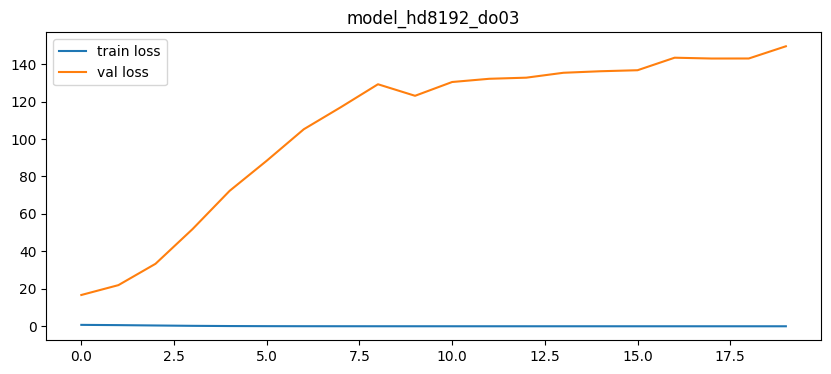

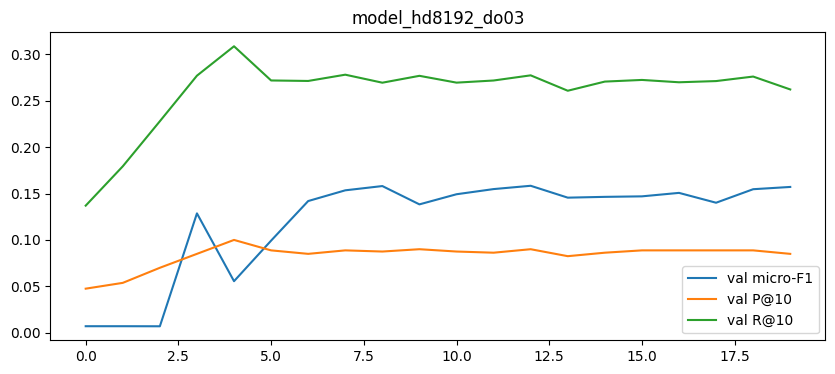

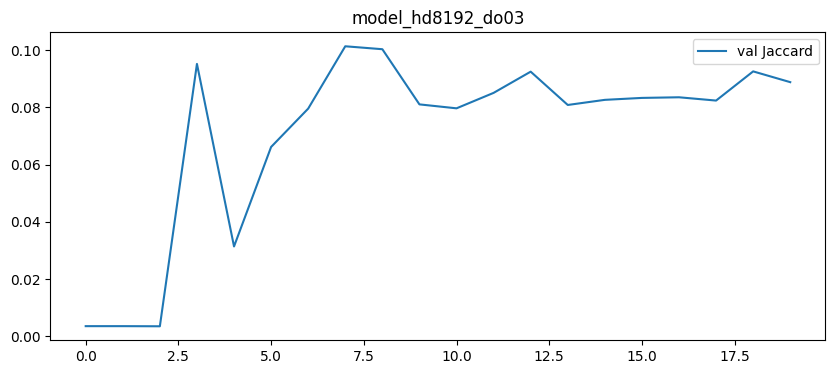


=== TEST ===
loss 153.7508 | micro-F1 0.1234 (P 0.1013 R 0.1579) | Jacc 0.0640 | P@10 0.0762 | R@10 0.1832


In [104]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.2, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.85it/s]


Epoch 01/20 | train loss 0.7544 | val loss 16.7505 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0550 | R@10 0.1486


100%|██████████| 10/10 [00:01<00:00,  6.30it/s]


Epoch 02/20 | train loss 0.6263 | val loss 22.1203 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0650 | R@10 0.2048


...

Epoch 18/20 | train loss 0.0069 | val loss 146.6646 | val micro-F1 0.1631 (P 0.1512 R 0.1770) | Jacc 0.0982 | P@10 0.0800 | R@10 0.2363


100%|██████████| 10/10 [00:01<00:00,  5.19it/s]


Epoch 19/20 | train loss 0.0066 | val loss 145.0339 | val micro-F1 0.1468 (P 0.1325 R 0.1646) | Jacc 0.0868 | P@10 0.0775 | R@10 0.2401


100%|██████████| 10/10 [00:01<00:00,  5.39it/s]


Epoch 20/20 | train loss 0.0064 | val loss 149.3394 | val micro-F1 0.1676 (P 0.1592 R 0.1770) | Jacc 0.0957 | P@10 0.0813 | R@10 0.2472


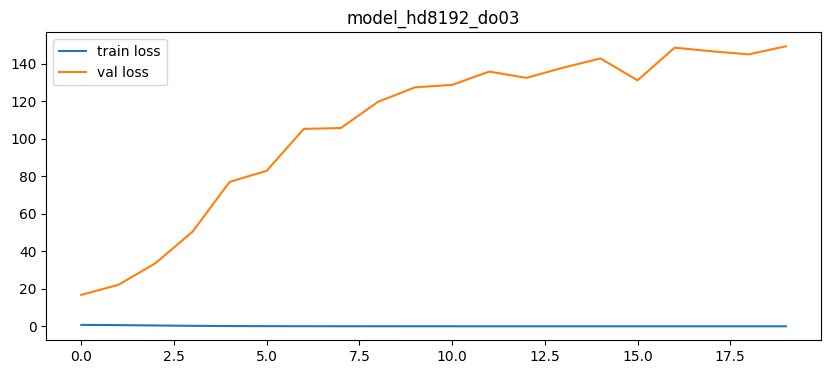

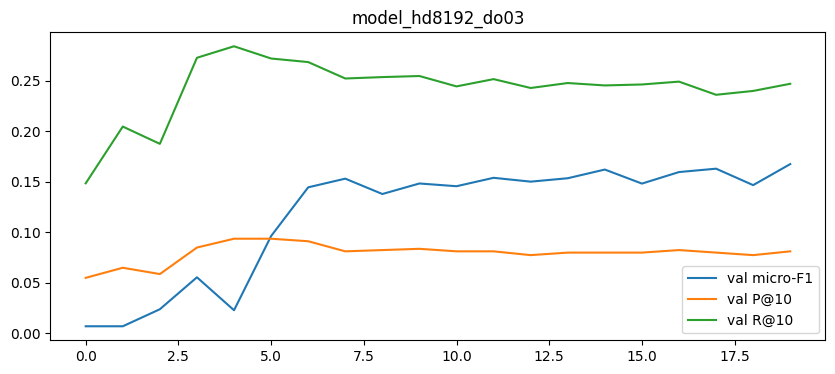

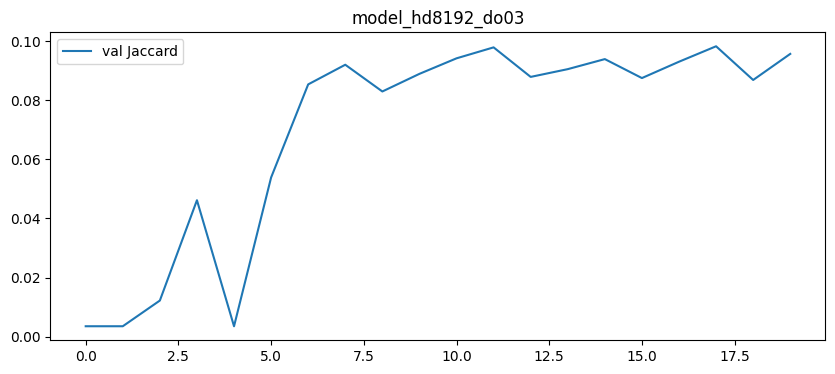


=== TEST ===
loss 163.5726 | micro-F1 0.1219 (P 0.1158 R 0.1287) | Jacc 0.0646 | P@10 0.0688 | R@10 0.1717


In [105]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.25, k_at=10)


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:02<00:00,  4.97it/s]


Epoch 01/20 | train loss 0.7543 | val loss 16.6619 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0625 | R@10 0.1924


100%|██████████| 10/10 [00:02<00:00,  4.67it/s]


Epoch 02/20 | train loss 0.6256 | val loss 21.7897 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0650 | R@10 0.1976


...

Epoch 18/20 | train loss 0.0068 | val loss 147.1501 | val micro-F1 0.1664 (P 0.1683 R 0.1646) | Jacc 0.0927 | P@10 0.0863 | R@10 0.2625


100%|██████████| 10/10 [00:01<00:00,  5.39it/s]


Epoch 19/20 | train loss 0.0066 | val loss 147.7719 | val micro-F1 0.1600 (P 0.1650 R 0.1553) | Jacc 0.0981 | P@10 0.0838 | R@10 0.2636


100%|██████████| 10/10 [00:02<00:00,  4.73it/s]


Epoch 20/20 | train loss 0.0062 | val loss 143.3634 | val micro-F1 0.1577 (P 0.1488 R 0.1677) | Jacc 0.0946 | P@10 0.0875 | R@10 0.2689


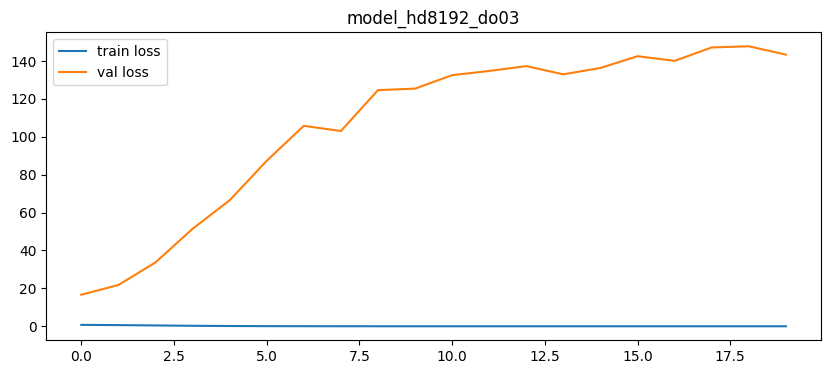

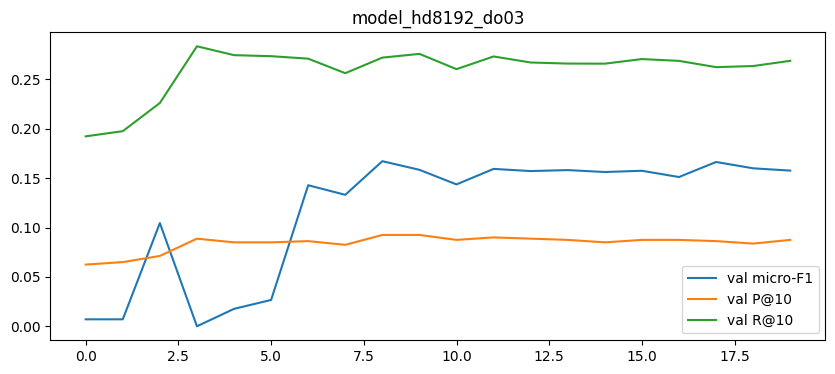

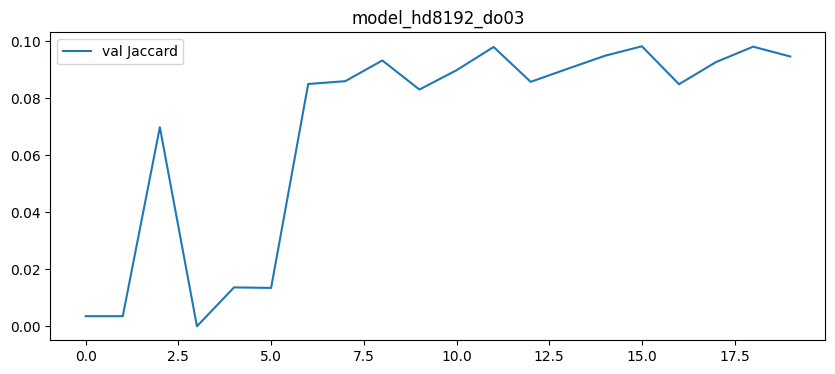


=== TEST ===
loss 141.3918 | micro-F1 0.1279 (P 0.1333 R 0.1228) | Jacc 0.0506 | P@10 0.0700 | R@10 0.1764


In [106]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=20, threshold=0.3, k_at=10)

We can choose threshold=0.15 and test the model on the longer training. We can observe the trend in the visualizations


===== TRAINING model_hd8192_do03 (hd=8192, do=0.3) =====


100%|██████████| 10/10 [00:01<00:00,  5.57it/s]


Epoch 01/50 | train loss 0.7535 | val loss 16.6839 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0650 | R@10 0.2181


100%|██████████| 10/10 [00:01<00:00,  5.88it/s]


Epoch 02/50 | train loss 0.6251 | val loss 22.1167 | val micro-F1 0.0070 (P 0.0035 R 1.0000) | Jacc 0.0035 | P@10 0.0650 | R@10 0.2075


...

Epoch 48/50 | train loss 0.0045 | val loss 176.5078 | val micro-F1 0.1517 (P 0.1294 R 0.1832) | Jacc 0.0967 | P@10 0.0825 | R@10 0.2567


100%|██████████| 10/10 [00:01<00:00,  5.17it/s]


Epoch 49/50 | train loss 0.0043 | val loss 179.0314 | val micro-F1 0.1552 (P 0.1330 R 0.1863) | Jacc 0.0953 | P@10 0.0850 | R@10 0.2598


100%|██████████| 10/10 [00:02<00:00,  4.44it/s]


Epoch 50/50 | train loss 0.0042 | val loss 184.0187 | val micro-F1 0.1603 (P 0.1511 R 0.1708) | Jacc 0.1006 | P@10 0.0863 | R@10 0.2606


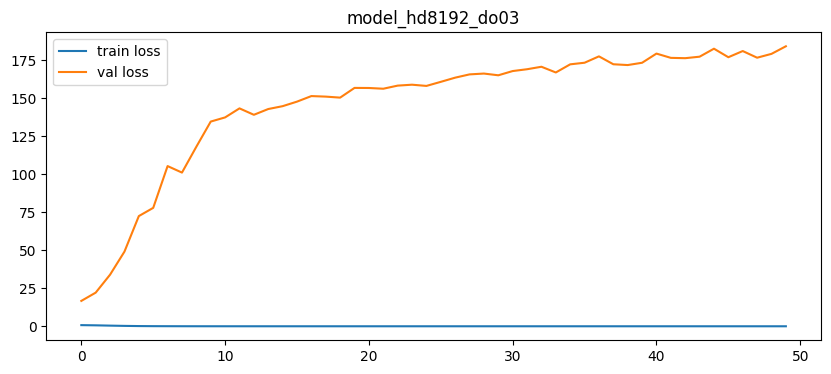

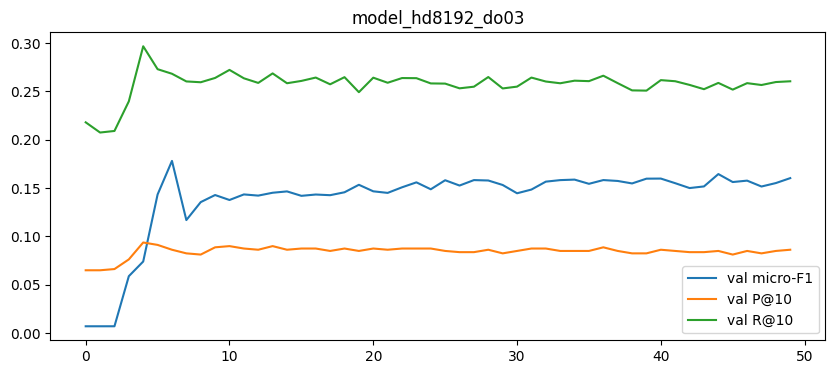

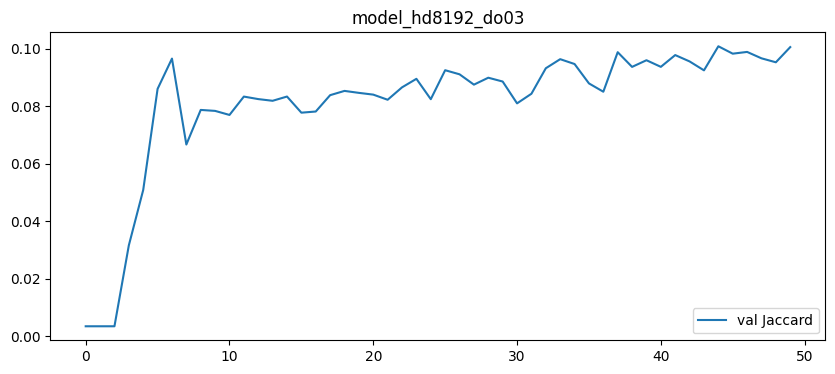


=== TEST ===
loss 125.7998 | micro-F1 0.1214 (P 0.1200 R 0.1228) | Jacc 0.0575 | P@10 0.0675 | R@10 0.1688


In [107]:
test_hiperparameters(hidden_dim=8192, dropout=0.3, lr=1e-3, weight_dec=1e-2, n_epochs=50, threshold=0.15, k_at=10)